In [1]:
!pip install google-play-scraper langdetect vaderSentiment wordcloud -q

import re, nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google_play_scraper import Sort, reviews
from langdetect import detect, DetectorFactory
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords'); nltk.download('wordnet')
DetectorFactory.seed = 0
sns.set_style('whitegrid')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
scraped_reviews, _ = reviews('com.duolingo', lang='en', country='in',
                             sort=Sort.NEWEST, count=2000)
df_duo = pd.DataFrame(scraped_reviews)[['userName', 'score', 'at', 'content']]
df_duo.rename(columns={'score': 'rating', 'at': 'timestamp'}, inplace=True)
df_duo['app'] = 'Duolingo'
print(f'Duolingo scraped: {len(df_duo)}')

Duolingo scraped: 2000


In [3]:
scraped_babbel, _ = reviews('com.babbel.mobile.android.en', lang='en', country='in',
                            sort=Sort.NEWEST, count=2000)
df_bab = pd.DataFrame(scraped_babbel)[['userName', 'score', 'at', 'content']]
df_bab.rename(columns={'score': 'rating', 'at': 'timestamp'}, inplace=True)
df_bab['app'] = 'Babbel'
print(f'Babbel scraped: {len(df_bab)}')

Babbel scraped: 2000


In [4]:
def is_english(text):
    text = str(text).strip()
    if not text or sum(c.isascii() for c in text) / len(text) < 0.9:
        return False
    try:
        return detect(text) == 'en'
    except Exception:
        return False

df = pd.concat([df_duo, df_bab], ignore_index=True)
df = df.dropna(subset=['content']).drop_duplicates(subset=['userName', 'content'])
df = df[df['content'].apply(is_english)]

1. DataFrame Shape:
(3063, 5)


2. DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3063 entries, 1 to 3999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   userName   3063 non-null   object        
 1   rating     3063 non-null   int64         
 2   timestamp  3063 non-null   datetime64[ns]
 3   content    3063 non-null   object        
 4   app        3063 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 143.6+ KB


3. Missing Values:
userName     0
rating       0
timestamp    0
content      0
app          0
dtype: int64


4. Duplicate Reviews (full row duplicates):
Number of duplicate rows: 0


5. Number of Reviews by App:
app
Babbel      1767
Duolingo    1296
Name: count, dtype: int64


6. Rating Distribution by App:
rating      1    2    3    4    5
app                              
Babbel    594  210  207  182  574
Duolingo  130   33   59  206  868



/tmp/ipykernel_764/2504831769.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='app', data=df, palette='viridis')


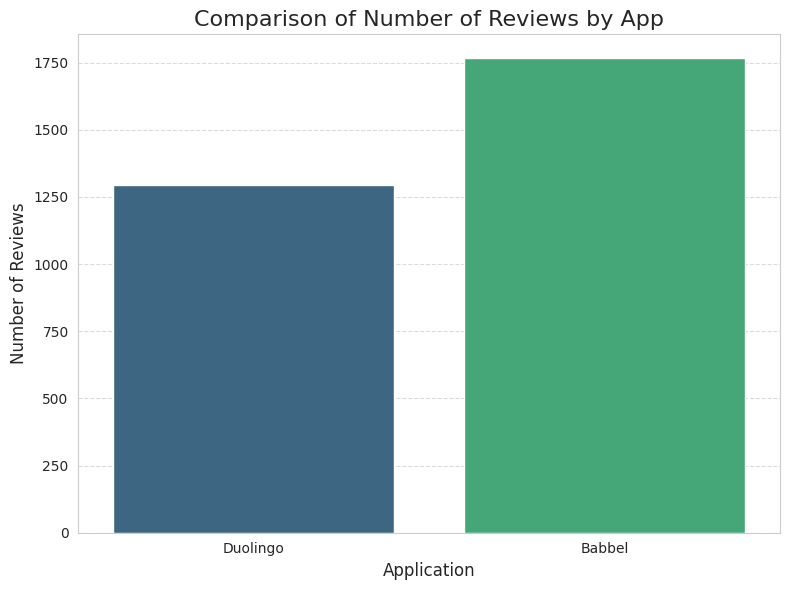

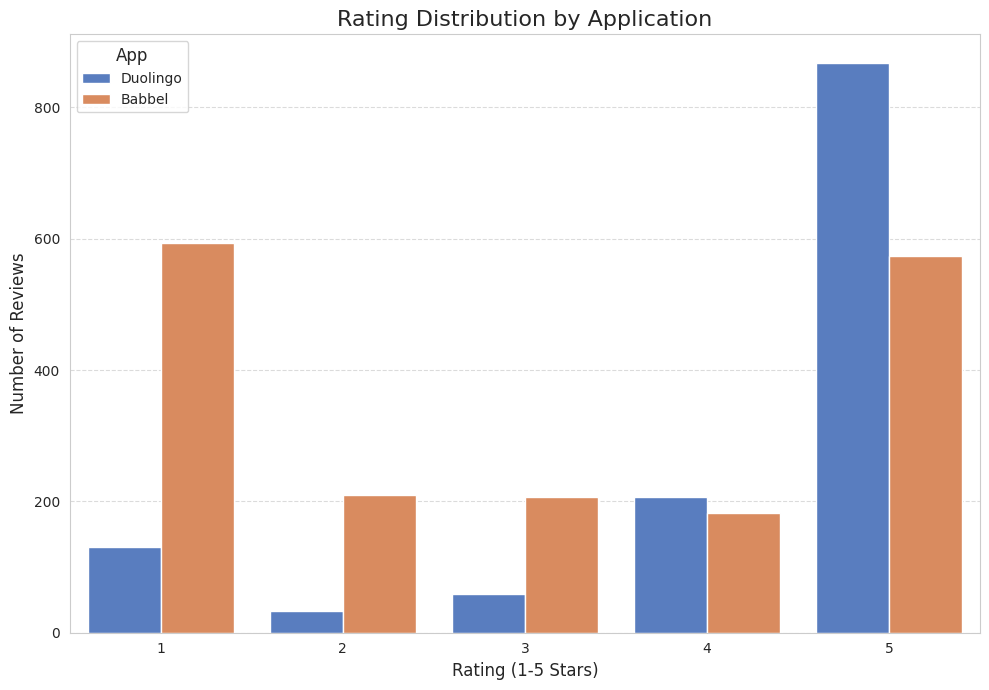

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Display the shape of the dataframe
print('1. DataFrame Shape:')
print(df.shape)
print('\n' + '='*50 + '\n')

# 2. Display df.info()
print('2. DataFrame Info:')
df.info()
print('\n' + '='*50 + '\n')

# 3. Check missing values for every column
print('3. Missing Values:')
print(df.isnull().sum())
print('\n' + '='*50 + '\n')

# 4. Check duplicate reviews
print('4. Duplicate Reviews (full row duplicates):')
print(f'Number of duplicate rows: {df.duplicated().sum()}')
# Note: Duplicates by 'userName' and 'content' were already handled during data preprocessing.
print('\n' + '='*50 + '\n')

# 5. Show the number of reviews for Duolingo and Babbel
print('5. Number of Reviews by App:')
print(df['app'].value_counts())
print('\n' + '='*50 + '\n')

# 6. Show the rating distribution from 1 to 5 separately for each app
print('6. Rating Distribution by App:')
print(pd.crosstab(df['app'], df['rating']))
print('\n' + '='*50 + '\n')

# 7. Calculate and display the average rating for each app
print('7. Average Rating by App:')
print(df.groupby('app')['rating'].mean())
print('\n' + '='*50 + '\n')

# 8. Display the minimum and maximum review dates for each app
print('8. Minimum and Maximum Review Dates by App:')
print('Minimum Review Date:')
print(df.groupby('app')['timestamp'].min())
print('\nMaximum Review Date:')
print(df.groupby('app')['timestamp'].max())
print('\n' + '='*50 + '\n')

# 9. Create a suitable bar chart comparing the number of reviews by app
plt.figure(figsize=(8, 6))
sns.countplot(x='app', data=df, palette='viridis')
plt.title('Comparison of Number of Reviews by App', fontsize=16)
plt.xlabel('Application', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n' + '='*50 + '\n')

# 10. Create a grouped/count plot showing rating distribution by app
plt.figure(figsize=(10, 7))
sns.countplot(x='rating', hue='app', data=df, palette='muted', order=sorted(df['rating'].unique()))
plt.title('Rating Distribution by Application', fontsize=16)
plt.xlabel('Rating (1-5 Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='App', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
print('--- Starting Data Cleaning ---')

initial_rows = len(df)
print(f'Initial number of rows: {initial_rows}')

# 1. Display the number of null values in content.
null_content_count = df['content'].isnull().sum()
print(f'\nNumber of null values in "content" column: {null_content_count}')

# 2. Count reviews where content is empty or contains only whitespace.
blank_content_count = df[df['content'].astype(str).str.strip().eq('')].shape[0]
print(f'Number of blank or whitespace-only content values: {blank_content_count}')

# 3. Remove rows where content is null or blank.
# First, handle actual nulls
df.dropna(subset=['content'], inplace=True)
# Then, handle empty strings or strings with only whitespace
df = df[df['content'].astype(str).str.strip().ne('')]

print('\nRemoved null and blank content rows.')

# 4. Remove duplicate reviews based on app and content.
duplicates_before_removal = df.duplicated(subset=['app', 'content']).sum()
df.drop_duplicates(subset=['app', 'content'], inplace=True)
print(f'Removed {duplicates_before_removal} duplicate reviews based on "app" and "content".')

# 5. Reset the dataframe index.
df.reset_index(drop=True, inplace=True)
print('DataFrame index reset.')

final_rows = len(df)
removed_reviews = initial_rows - final_rows

# 6. Print the number of rows before and after cleaning.
print(f'\nNumber of rows after cleaning: {final_rows}')

# 7. Print how many reviews were removed.
print(f'Total reviews removed during cleaning: {removed_reviews}')

# 8. Confirm that no null or blank review texts remain.
null_content_after = df['content'].isnull().sum()
blank_content_after = df[df['content'].astype(str).str.strip().eq('')].shape[0]

print(f'\nConfirmation - Null content values remaining: {null_content_after}')
print(f'Confirmation - Blank content values remaining: {blank_content_after}')

print('\n--- Data Cleaning Complete ---')


--- Starting Data Cleaning ---
Initial number of rows: 3063

Number of null values in "content" column: 0
Number of blank or whitespace-only content values: 0

Removed null and blank content rows.
Removed 39 duplicate reviews based on "app" and "content".
DataFrame index reset.

Number of rows after cleaning: 3024
Total reviews removed during cleaning: 39

Confirmation - Null content values remaining: 0
Confirmation - Blank content values remaining: 0

--- Data Cleaning Complete ---


In [7]:
# Create Review_Lower column with lowercase review text
df['Review_Lower'] = df['content'].astype(str).str.lower()

# Display 5 sample reviews for verification
df.head(5)


,userName,rating,timestamp,content,app,Review_Lower
0,Junior Moepi,5,2026-09-01 14:46:54,very good for learning languages thank you for...,Duolingo,very good for learning languages thank you for...
1,Shilpi Chakraborty,5,2026-09-01 14:46:25,"bonjour, this app has helped me learn Francis ...",Duolingo,"bonjour, this app has helped me learn francis ..."
2,Derick Mashiane,5,2026-09-01 14:46:14,Makes learning fun,Duolingo,makes learning fun
3,Prakash Upreti,5,2026-09-01 14:44:43,very good app it's make my English better,Duolingo,very good app it's make my english better
4,Vicky Pro,4,2026-09-01 14:43:21,that's super 👍 Duolingo,Duolingo,that's super 👍 duolingo


In [8]:
def clean_text_for_analysis(text):
    # 1. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove punctuation and special characters (keeping only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text) # Keep only lowercase alphabet and spaces
    # 4. Remove unnecessary numbers (already handled by previous step as we keep only letters and spaces)
    # 5. Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # 6. Stripping leading and trailing whitespace
    text = text.strip()
    return text

# Create Review_NoSpecialChars column by applying the cleaning function
df['Review_NoSpecialChars'] = df['Review_Lower'].apply(clean_text_for_analysis)

# Display Review_Lower and Review_NoSpecialChars for 5 examples
df[['Review_Lower', 'Review_NoSpecialChars']].head(5)

,Review_Lower,Review_NoSpecialChars
0,very good for learning languages thank you for...,very good for learning languages thank you for...
1,"bonjour, this app has helped me learn francis ...",bonjour this app has helped me learn francis a...
2,makes learning fun,makes learning fun
3,very good app it's make my english better,very good app its make my english better
4,that's super 👍 duolingo,thats super duolingo


In [9]:
import nltk
from nltk.tokenize import word_tokenize

# Download NLTK 'punkt' and 'punkt_tab' tokenizer models if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Create Tokens column by tokenizing Review_NoSpecialChars
df['Tokens'] = df['Review_NoSpecialChars'].apply(word_tokenize)

# Display the original cleaned text and its tokens for 5 sample reviews
df[['Review_NoSpecialChars', 'Tokens']].head(5)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Review_NoSpecialChars,Tokens
0,very good for learning languages thank you for...,"[very, good, for, learning, languages, thank, ..."
1,bonjour this app has helped me learn francis a...,"[bonjour, this, app, has, helped, me, learn, f..."
2,makes learning fun,"[makes, learning, fun]"
3,very good app its make my english better,"[very, good, app, its, make, my, english, better]"
4,thats super duolingo,"[thats, super, duolingo]"


In [10]:
from nltk.corpus import stopwords

# Get NLTK English stopwords
stop_words = set(stopwords.words('english'))

# Define negation words to retain for sentiment analysis
# These words often reverse the sentiment of a sentence, so removing them would be detrimental.
negation_words = ['no', 'not', 'nor', 'never', 'none', 'nothing', 'neither', 'cannot', 'without']

# Create a custom stopword list by removing negation words
# We also want to keep domain-specific words (like 'app', 'lesson', 'language', 'subscription', 'course')
# at this stage as they might carry important analytical information.
custom_stopwords = [word for word in stop_words if word not in negation_words]

def remove_stopwords(tokens):
    """Removes custom stopwords from a list of tokens."""
    return [word for word in tokens if word not in custom_stopwords]

# Apply the stopword removal function to create a new column 'Tokens_NoStop'
df['Tokens_NoStop'] = df['Tokens'].apply(remove_stopwords)

# Display the 'Tokens' and 'Tokens_NoStop' columns for 5 sample reviews
df[['Tokens', 'Tokens_NoStop']].head(5)


,Tokens,Tokens_NoStop
0,"[very, good, for, learning, languages, thank, ...","[good, learning, languages, thank, app]"
1,"[bonjour, this, app, has, helped, me, learn, f...","[bonjour, app, helped, learn, francis, school,..."
2,"[makes, learning, fun]","[makes, learning, fun]"
3,"[very, good, app, its, make, my, english, better]","[good, app, make, english, better]"
4,"[thats, super, duolingo]","[thats, super, duolingo]"


In [11]:
from nltk.stem import WordNetLemmatizer

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to lemmatize a list of tokens
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply the lemmatization function to create a new column 'Tokens_Lemmatized'
df['Tokens_Lemmatized'] = df['Tokens_NoStop'].apply(lemmatize_tokens)

# Display the 'Tokens_NoStop' and 'Tokens_Lemmatized' columns for 5 sample reviews
df[['Tokens_NoStop', 'Tokens_Lemmatized']].head(5)

,Tokens_NoStop,Tokens_Lemmatized
0,"[good, learning, languages, thank, app]","[good, learning, language, thank, app]"
1,"[bonjour, app, helped, learn, francis, school,...","[bonjour, app, helped, learn, francis, school,..."
2,"[makes, learning, fun]","[make, learning, fun]"
3,"[good, app, make, english, better]","[good, app, make, english, better]"
4,"[thats, super, duolingo]","[thats, super, duolingo]"


In [12]:
# Reuse negation_words list from previous step for consistency
# negation_words = ['no', 'not', 'nor', 'never', 'none', 'nothing', 'neither', 'cannot', 'without']

def clean_final_tokens(tokens):
    cleaned_tokens = []
    for token in tokens:
        # Ensure the token is alphabetic or is one of the important negation words
        # This prevents removal of negations like 'not' which are crucial for sentiment analysis
        # It also implicitly handles domain-specific words if they are alphabetic and meet length criteria.
        if (token.isalpha() or token in negation_words) and len(token) >= 3:
            cleaned_tokens.append(token)
    return cleaned_tokens

# Apply the final cleaning function to create the 'Tokens_Final' column
df['Tokens_Final'] = df['Tokens_Lemmatized'].apply(clean_final_tokens)

# Display the 'Tokens_Lemmatized' and 'Tokens_Final' columns for 5 sample reviews
df[['Tokens_Lemmatized', 'Tokens_Final']].head(5)

,Tokens_Lemmatized,Tokens_Final
0,"[good, learning, language, thank, app]","[good, learning, language, thank, app]"
1,"[bonjour, app, helped, learn, francis, school,...","[bonjour, app, helped, learn, francis, school,..."
2,"[make, learning, fun]","[make, learning, fun]"
3,"[good, app, make, english, better]","[good, app, make, english, better]"
4,"[thats, super, duolingo]","[thats, super, duolingo]"


In [13]:
from collections import Counter

# 1. Convert Tokens_Final back into a single string for Clean_Text
df['Clean_Text'] = df['Tokens_Final'].apply(lambda tokens: ' '.join(tokens))

# 2. Display most frequent words from Tokens_Final to inform generic stopword selection
all_final_tokens = [token for sublist in df['Tokens_Final'] for token in sublist]
word_freq = Counter(all_final_tokens)

print("\nMost Frequent Words (from Tokens_Final) to help identify generic stopwords for Clean_Text_WC:")
for word, freq in word_freq.most_common(30):
    print(f"- '{word}': {freq}")

# --- Create Clean_Text_WC with additional generic stopwords removed ---

# These are additional generic words identified from the most frequent list
# that are not specific to app reviews or language learning, and are not in the 'keep' list.
# The goal is to remove words that are highly frequent but don't add much unique meaning
# for word clouds, focusing on more distinctive terms.
additional_generic_stopwords = [
    'good', 'like', 'really', 'great', 'love', 'one', 'get', 'time', 'use', 'free',
    'much', 'day', 'easy', 'better', 'even', 'new', 'would', 'way'
]

# Combine with any other stopwords if necessary, but keep it focused on the *additional* ones
# that might have slipped past NLTK's default or were explicitly kept for sentiment.

# The user specified words NOT to remove (domain-specific or important for analysis):
words_to_keep_explicitly = [
    'subscription', 'premium', 'price', 'lesson', 'course', 'grammar', 'audio',
    'speaking', 'vocabulary', 'customer', 'support', 'login', 'update',
    'app', 'language', 'learning', 'learn', 'duolingo', 'babbel', 'not', 'dont', 'doesnt', 'word', 'spanish'
]

# Filter out any 'words_to_keep_explicitly' from 'additional_generic_stopwords'
filtered_generic_stopwords = [word for word in additional_generic_stopwords if word not in words_to_keep_explicitly]

def remove_wc_stopwords(tokens):
    return [word for word in tokens if word not in filtered_generic_stopwords]

# Apply the new stopword removal to create 'Tokens_WC'
df['Tokens_WC'] = df['Tokens_Final'].apply(remove_wc_stopwords)

# Join 'Tokens_WC' back into a single string for 'Clean_Text_WC'
df['Clean_Text_WC'] = df['Tokens_WC'].apply(lambda tokens: ' '.join(tokens))

# Display content, Clean_Text, and Clean_Text_WC for 5 sample reviews
print("\nSample reviews showing 'content', 'Clean_Text', and 'Clean_Text_WC':")
display(df[['content', 'Clean_Text', 'Clean_Text_WC']].sample(5, random_state=42))


Most Frequent Words (from Tokens_Final) to help identify generic stopwords for Clean_Text_WC:
- 'app': 1359
- 'language': 870
- 'learning': 670
- 'learn': 633
- 'not': 620
- 'lesson': 499
- 'good': 496
- 'like': 413
- 'duolingo': 337
- 'really': 297
- 'word': 270
- 'great': 262
- 'love': 225
- 'one': 224
- 'get': 214
- 'time': 213
- 'dont': 213
- 'use': 211
- 'want': 198
- 'free': 196
- 'much': 191
- 'day': 191
- 'easy': 182
- 'doesnt': 182
- 'subscription': 181
- 'better': 176
- 'even': 174
- 'new': 173
- 'would': 170
- 'spanish': 170

Sample reviews showing 'content', 'Clean_Text', and 'Clean_Text_WC':


,content,Clean_Text,Clean_Text_WC
3015,pronunciation very unclear in some audio,pronunciation unclear audio,pronunciation unclear audio
251,"I didn't miss my Spanish lesson, don't wanna k...",didnt miss spanish lesson dont wan know happen...,didnt miss spanish lesson dont wan know happen...
1709,problem 1: theres hardly any language options....,problem there hardly language option wanted le...,problem there hardly language option wanted le...
1609,Exactly 1 lesson before you need to subscribe ...,exactly lesson need subscribe premium plan not...,exactly lesson need subscribe premium plan not...
1018,sooo boring can you level it up,sooo boring level,sooo boring level



--- TF-IDF Analysis (All Reviews) ---

Top 20 Terms by Mean TF-IDF Score (All Reviews):

| Term     |   Mean_TFIDF |
|:---------|-------------:|
| app      |    0.0532572 |
| good     |    0.0401064 |
| language |    0.0368423 |
| learning |    0.0353162 |
| learn    |    0.0316048 |
| not      |    0.0254541 |
| great    |    0.0249498 |
| love     |    0.0221593 |
| lesson   |    0.0218551 |
| duolingo |    0.0199258 |
| like     |    0.0192775 |
| easy     |    0.0186193 |
| really   |    0.0177742 |
| nice     |    0.0165359 |
| best     |    0.016435  |
| fun      |    0.0142747 |
| free     |    0.0135382 |
| much     |    0.013091  |
| word     |    0.0130715 |
| english  |    0.0129735 |


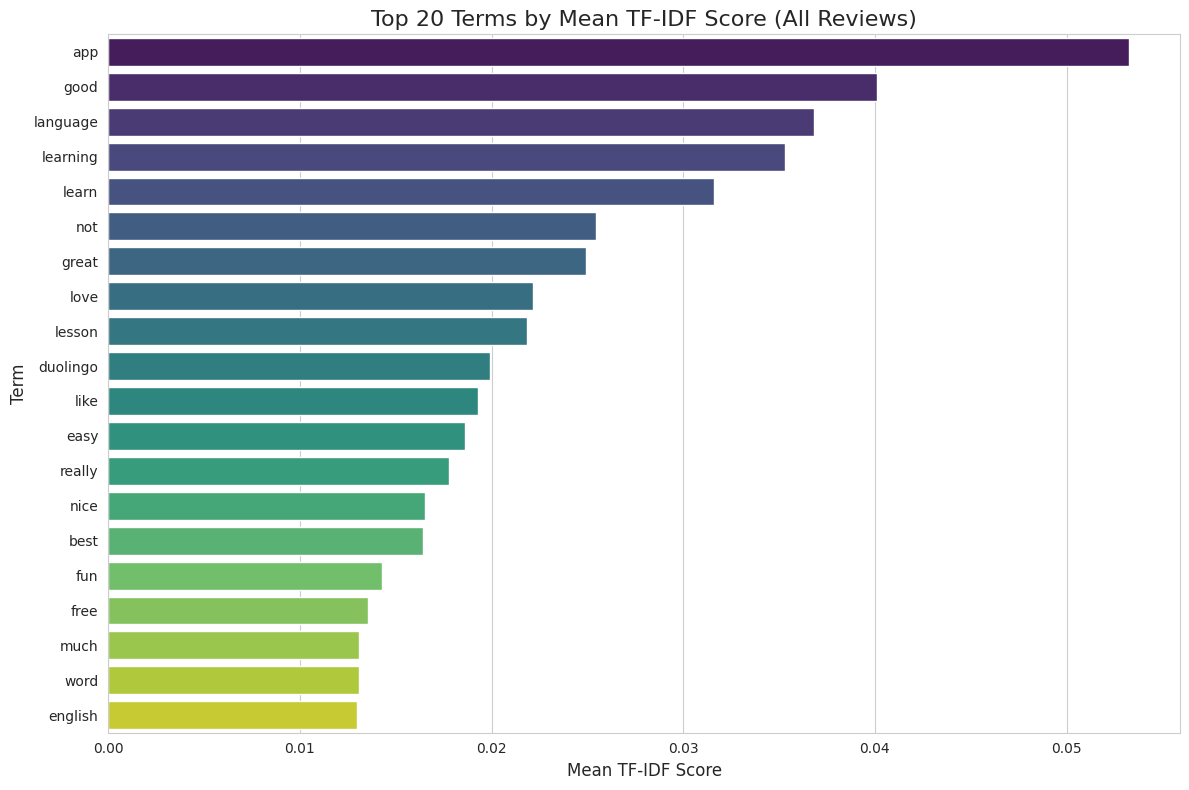


--- TF-IDF Analysis (Duolingo Reviews) ---

Top 15 Terms by Mean TF-IDF Score (Duolingo Reviews):

| Term     |   Mean_TFIDF |
|:---------|-------------:|
| app      |    0.0748033 |
| good     |    0.0665309 |
| learning |    0.0508987 |
| language |    0.0426767 |
| learn    |    0.0418919 |
| love     |    0.0361432 |
| nice     |    0.0313694 |
| best     |    0.031262  |
| duolingo |    0.0296143 |
| easy     |    0.0267774 |
| great    |    0.0265306 |
| really   |    0.0258331 |
| fun      |    0.0251214 |
| english  |    0.024317  |
| good app |    0.0211036 |

--- TF-IDF Analysis (Babbel Reviews) ---

Top 15 Terms by Mean TF-IDF Score (Babbel Reviews):

| Term         |   Mean_TFIDF |
|:-------------|-------------:|
| app          |    0.0496128 |
| language     |    0.0398352 |
| not          |    0.0340538 |
| learning     |    0.0319758 |
| learn        |    0.0312291 |
| lesson       |    0.0303981 |
| great        |    0.0263003 |
| good         |    0.0253762 |
| like  

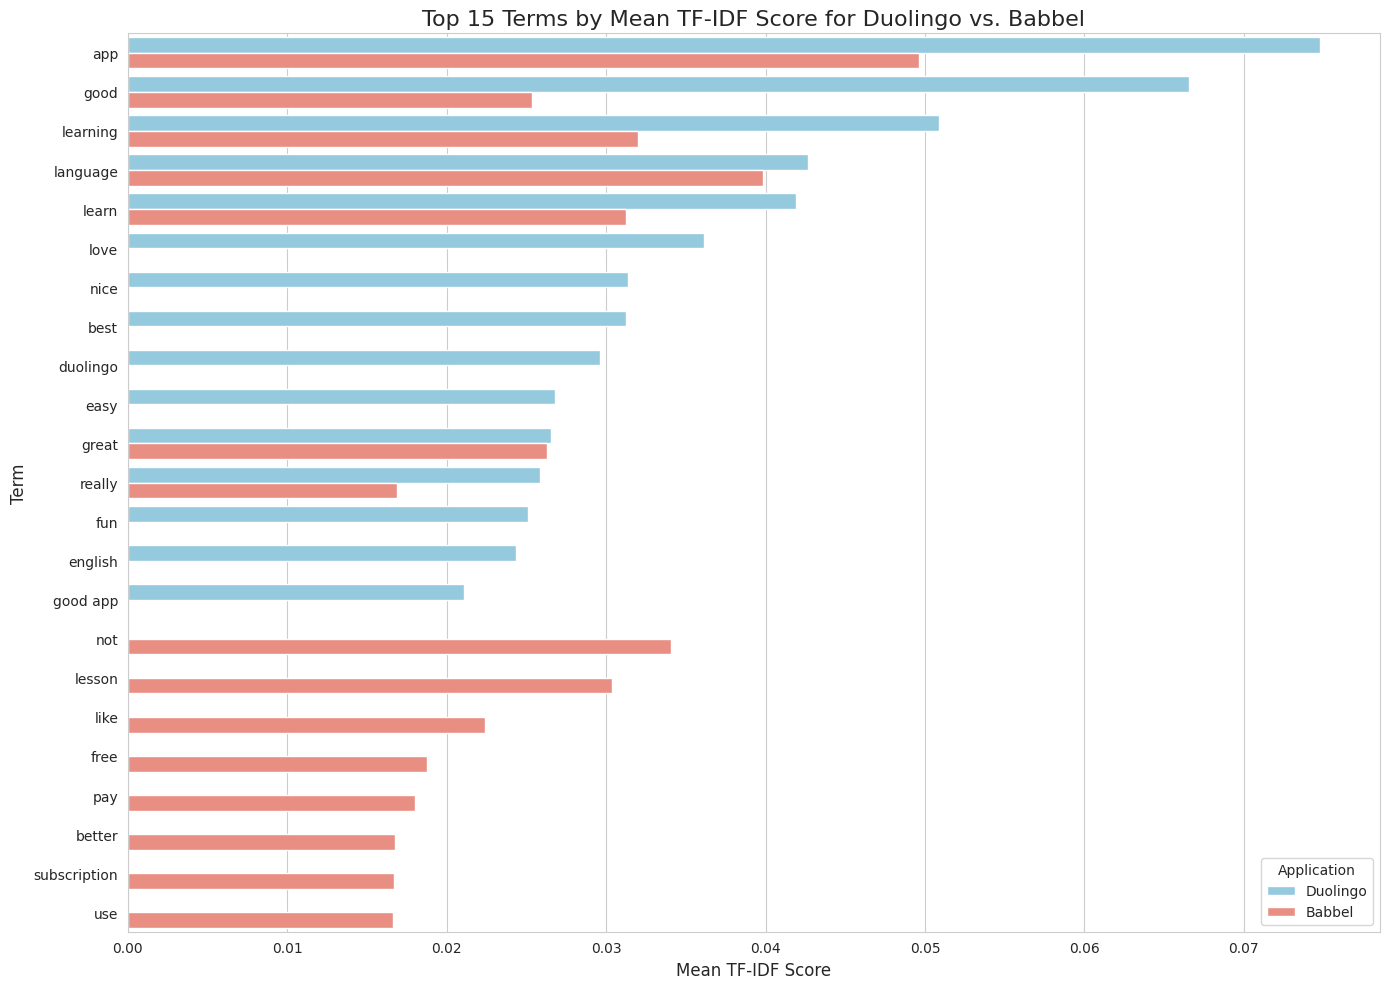

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. TF-IDF for all reviews ---
print("\n--- TF-IDF Analysis (All Reviews) ---")

# Initialize TfidfVectorizer with specified parameters
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3), # Unigrams, bigrams, and trigrams
    max_features=15000, # Limit to top 15,000 features
    min_df=5,           # Ignore terms that appear in less than 5 documents
    max_df=0.9          # Ignore terms that appear in more than 90% of documents
)

# Fit and transform the 'Clean_Text' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Clean_Text'])

# Get feature names (terms)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate the mean TF-IDF score for every term across all reviews
mean_tfidf_scores = tfidf_matrix.mean(axis=0).A1

# Create a DataFrame for terms and their mean TF-IDF scores
mean_tfidf_df = pd.DataFrame({
    'Term': feature_names,
    'Mean_TFIDF': mean_tfidf_scores
}).sort_values(by='Mean_TFIDF', ascending=False)

print("\nTop 20 Terms by Mean TF-IDF Score (All Reviews):\n")
print(mean_tfidf_df.head(20).to_markdown(index=False))

# Create a horizontal bar chart of the top 20 TF-IDF terms
plt.figure(figsize=(12, 8))
sns.barplot(x='Mean_TFIDF', y='Term', hue='Term', data=mean_tfidf_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Terms by Mean TF-IDF Score (All Reviews)', fontsize=16)
plt.xlabel('Mean TF-IDF Score', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. TF-IDF for Duolingo reviews ---
print("\n--- TF-IDF Analysis (Duolingo Reviews) ---")

df_duolingo = df[df['app'] == 'Duolingo']

# Fit and transform 'Clean_Text' for Duolingo reviews
tfidf_vectorizer_duolingo = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=15000,
    min_df=5,
    max_df=0.9
)
tfidf_matrix_duolingo = tfidf_vectorizer_duolingo.fit_transform(df_duolingo['Clean_Text'])
feature_names_duolingo = tfidf_vectorizer_duolingo.get_feature_names_out()
mean_tfidf_scores_duolingo = tfidf_matrix_duolingo.mean(axis=0).A1

mean_tfidf_df_duolingo = pd.DataFrame({
    'Term': feature_names_duolingo,
    'Mean_TFIDF': mean_tfidf_scores_duolingo
}).sort_values(by='Mean_TFIDF', ascending=False)

print("\nTop 15 Terms by Mean TF-IDF Score (Duolingo Reviews):\n")
print(mean_tfidf_df_duolingo.head(15).to_markdown(index=False))

# --- 3. TF-IDF for Babbel reviews ---
print("\n--- TF-IDF Analysis (Babbel Reviews) ---")

df_babbel = df[df['app'] == 'Babbel']

# Fit and transform 'Clean_Text' for Babbel reviews
tfidf_vectorizer_babbel = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=15000,
    min_df=5,
    max_df=0.9
)
tfidf_matrix_babbel = tfidf_vectorizer_babbel.fit_transform(df_babbel['Clean_Text'])
feature_names_babbel = tfidf_vectorizer_babbel.get_feature_names_out()
mean_tfidf_scores_babbel = tfidf_matrix_babbel.mean(axis=0).A1

mean_tfidf_df_babbel = pd.DataFrame({
    'Term': feature_names_babbel,
    'Mean_TFIDF': mean_tfidf_scores_babbel
}).sort_values(by='Mean_TFIDF', ascending=False)

print("\nTop 15 Terms by Mean TF-IDF Score (Babbel Reviews):\n")
print(mean_tfidf_df_babbel.head(15).to_markdown(index=False))

# --- 4. Comparison Visualization (Top 15 for Each App) ---
print("\n--- Visual Comparison of Top TF-IDF Terms by App ---")

top_15_duolingo = mean_tfidf_df_duolingo.head(15).copy()
top_15_duolingo['App'] = 'Duolingo'

top_15_babbel = mean_tfidf_df_babbel.head(15).copy()
top_15_babbel['App'] = 'Babbel'

comparison_df = pd.concat([top_15_duolingo, top_15_babbel])

plt.figure(figsize=(14, 10))
sns.barplot(x='Mean_TFIDF', y='Term', hue='App', data=comparison_df, palette={'Duolingo': 'skyblue', 'Babbel': 'salmon'})
plt.title('Top 15 Terms by Mean TF-IDF Score for Duolingo vs. Babbel', fontsize=16)
plt.xlabel('Mean TF-IDF Score', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.legend(title='Application')
plt.tight_layout()
plt.show()


--- Rating-Based Sentiment Classification ---

Overall Rating-Based Sentiment Distribution:
| Rating_Sentiment   |   Count |   Percentage |
|:-------------------|--------:|-------------:|
| Positive           |    1795 |        59.36 |
| Negative           |     963 |        31.85 |
| Neutral            |     266 |         8.8  |

Rating-Based Sentiment Distribution by App:

Duolingo Sentiment Distribution (Count):

| Rating_Sentiment   | Duolingo   |
|:-------------------|:-----------|
| Negative           | 163        |
| Neutral            | 59         |
| Positive           | 1048       |

Duolingo Sentiment Distribution (Percentage):

| Rating_Sentiment   | Duolingo   |
|:-------------------|:-----------|
| Negative           | 12.83      |
| Neutral            | 4.65       |
| Positive           | 82.52      |

Babbel Sentiment Distribution (Count):

| Rating_Sentiment   | Babbel   |
|:-------------------|:---------|
| Negative           | 800      |
| Neutral            | 207  

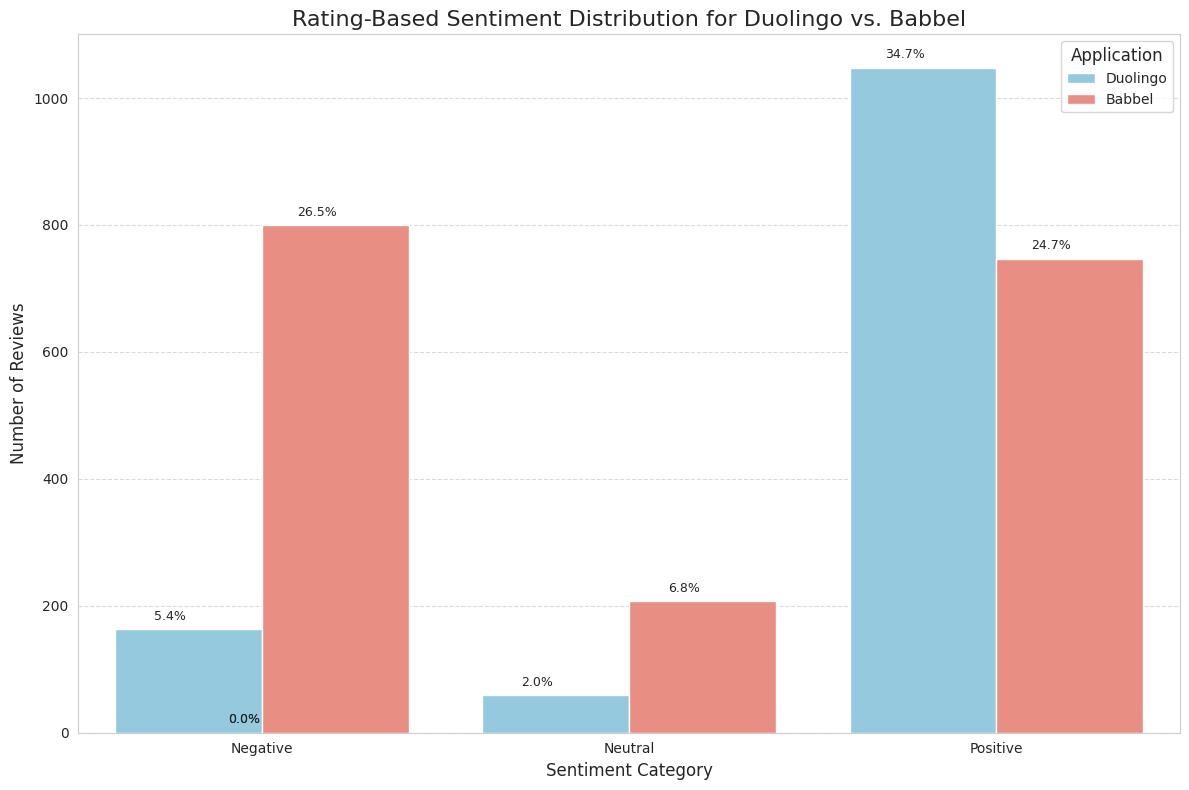

In [15]:
# This section performs a rating-based sentiment classification.
# It's important to note that this is a proxy for sentiment based purely on the numerical rating provided by the user,
# and does not involve natural language processing of the review text. Text-based sentiment analysis would yield
# different results and deeper insights.

print("\n--- Rating-Based Sentiment Classification ---")

# 1. Create 'Rating_Sentiment' column
def get_rating_sentiment(rating):
    if rating in [1, 2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    elif rating in [4, 5]:
        return 'Positive'
    return 'Unknown'

df['Rating_Sentiment'] = df['rating'].apply(get_rating_sentiment)

# 2. Display the count and percentage of Positive, Neutral, and Negative reviews (Overall)
print("\nOverall Rating-Based Sentiment Distribution:")
sentiment_counts = df['Rating_Sentiment'].value_counts()
sentiment_percentages = df['Rating_Sentiment'].value_counts(normalize=True) * 100

overall_sentiment_df = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_percentages
}).round(2)
print(overall_sentiment_df.to_markdown())

# 3. Show the sentiment distribution separately for Duolingo and Babbel
print("\nRating-Based Sentiment Distribution by App:")
sentiment_by_app = df.groupby('app')['Rating_Sentiment'].value_counts().unstack(fill_value=0)
sentiment_by_app_percentage = df.groupby('app')['Rating_Sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100

print("\nDuolingo Sentiment Distribution (Count):\n")
print(sentiment_by_app.loc['Duolingo'].to_markdown(numalign="left", stralign="left"))
print("\nDuolingo Sentiment Distribution (Percentage):\n")
print(sentiment_by_app_percentage.loc['Duolingo'].round(2).to_markdown(numalign="left", stralign="left"))

print("\nBabbel Sentiment Distribution (Count):\n")
print(sentiment_by_app.loc['Babbel'].to_markdown(numalign="left", stralign="left"))
print("\nBabbel Sentiment Distribution (Percentage):\n")
print(sentiment_by_app_percentage.loc['Babbel'].round(2).to_markdown(numalign="left", stralign="left"))

# 4. Create a grouped bar chart comparing Positive, Neutral, and Negative rating-based sentiment between the two apps
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='Rating_Sentiment', hue='app', data=df, palette={'Duolingo': 'skyblue', 'Babbel': 'salmon'}, order=['Negative', 'Neutral', 'Positive'])

# Add percentages on top of the bars
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05 # Adjust x position
    y = p.get_height() + 10 # Adjust y position slightly above the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

plt.title('Rating-Based Sentiment Distribution for Duolingo vs. Babbel', fontsize=16)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Application', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Unigram Frequency Analysis (Clean_Text_WC) ---

Overall Top 20 Most Frequent Words (from Clean_Text_WC):

| Word         |   Frequency |
|:-------------|------------:|
| app          |        1359 |
| language     |         870 |
| learning     |         670 |
| learn        |         633 |
| not          |         620 |
| lesson       |         499 |
| duolingo     |         337 |
| word         |         270 |
| dont         |         213 |
| want         |         198 |
| doesnt       |         182 |
| subscription |         181 |
| spanish      |         170 |
| cant         |         167 |
| babbel       |         167 |
| english      |         166 |
| make         |         164 |
| best         |         161 |
| also         |         157 |
| fun          |         150 |


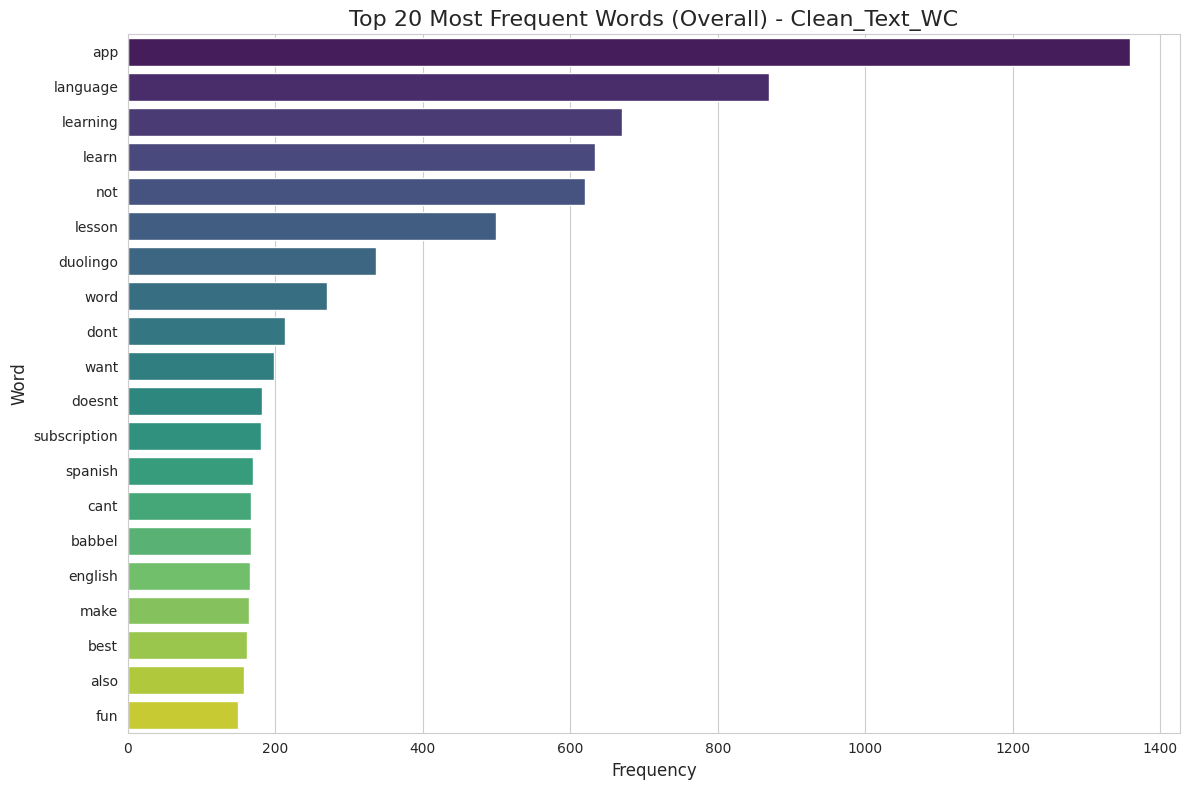


Duolingo Top 20 Most Frequent Words (from Clean_Text_WC):

| Word     |   Frequency |
|:---------|------------:|
| app      |         534 |
| language |         319 |
| learning |         301 |
| learn    |         264 |
| duolingo |         189 |
| not      |         128 |
| english  |         115 |
| best     |         112 |
| fun      |         102 |
| lesson   |          83 |
| make     |          78 |
| nice     |          75 |
| help     |          74 |
| word     |          68 |
| want     |          56 |
| dont     |          56 |
| also     |          51 |
| helpful  |          49 |
| spanish  |          47 |
| game     |          43 |


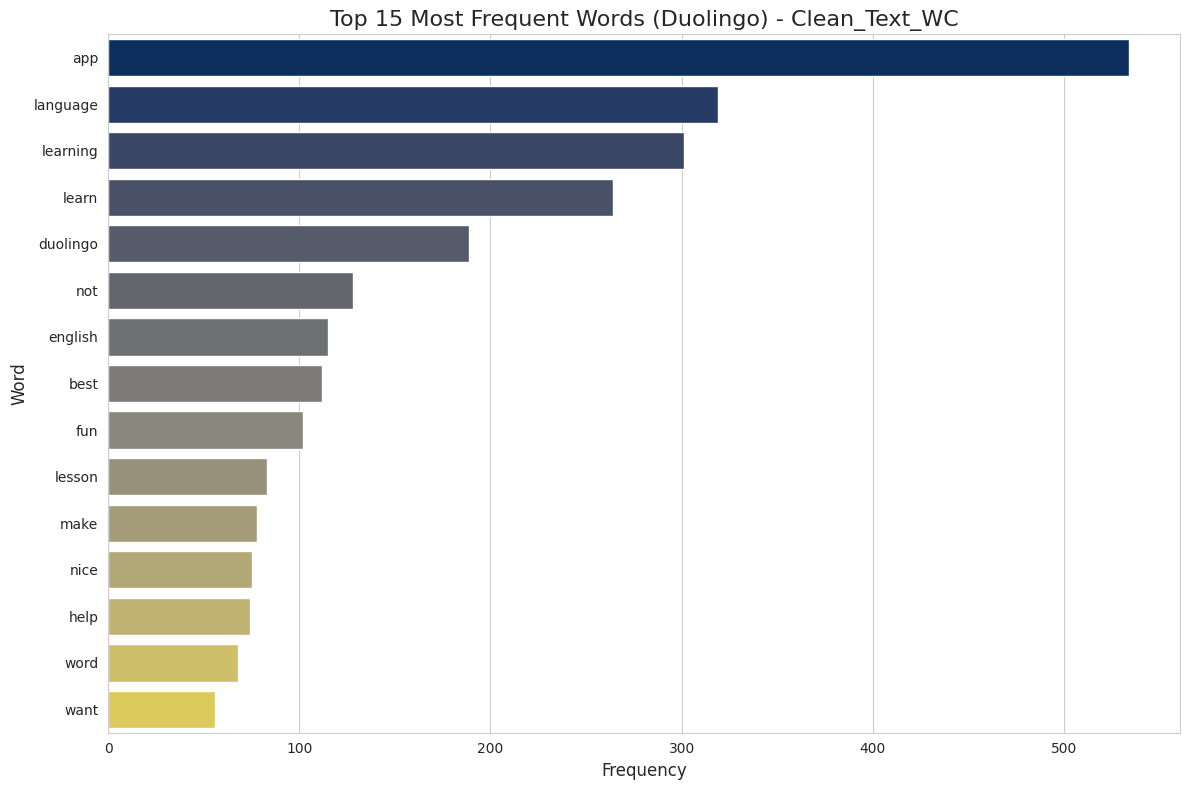


Babbel Top 20 Most Frequent Words (from Clean_Text_WC):

| Word         |   Frequency |
|:-------------|------------:|
| app          |         825 |
| language     |         551 |
| not          |         492 |
| lesson       |         416 |
| learn        |         369 |
| learning     |         369 |
| word         |         202 |
| subscription |         176 |
| babbel       |         164 |
| dont         |         157 |
| doesnt       |         156 |
| duolingo     |         148 |
| want         |         142 |
| cant         |         138 |
| pay          |         136 |
| spanish      |         123 |
| option       |         111 |
| speaking     |         111 |
| need         |         110 |
| also         |         106 |


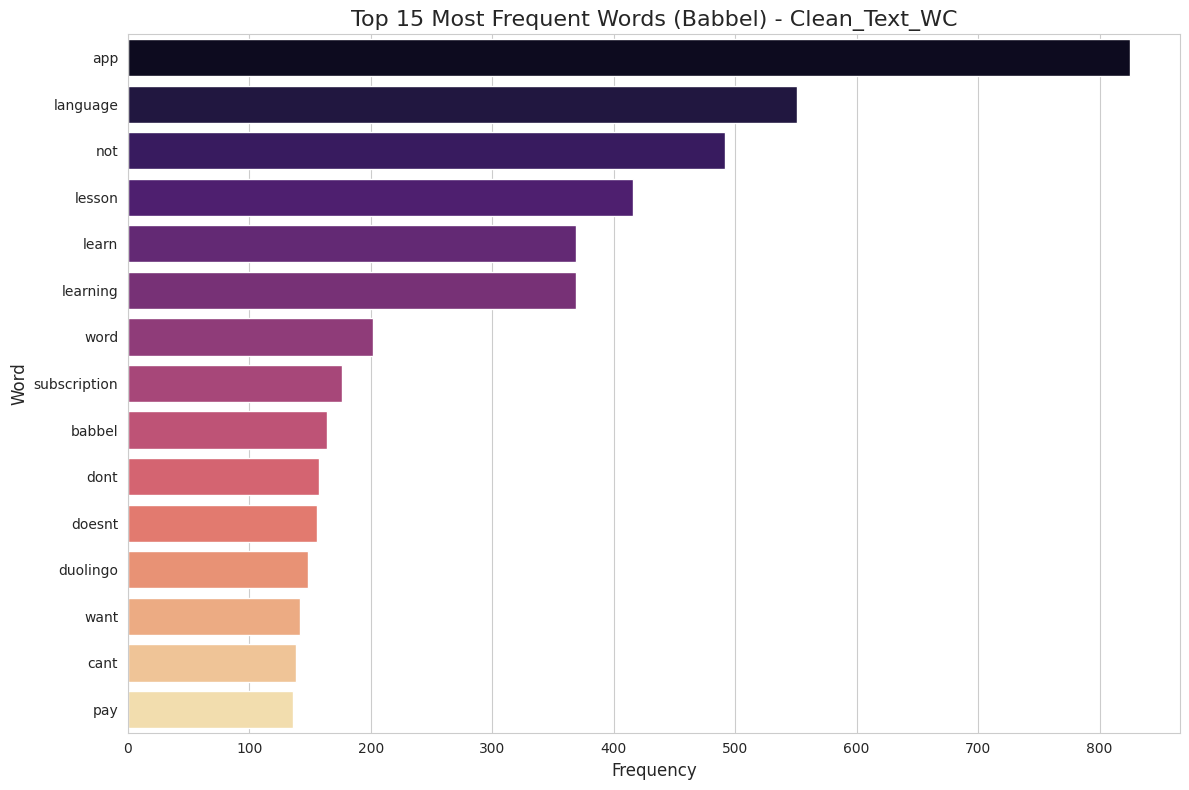

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Unigram Frequency Analysis (Clean_Text_WC) ---")

# Helper function to get word frequencies
def get_word_frequencies(text_series, top_n=None):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    if top_n:
        return pd.DataFrame(word_counts.most_common(top_n), columns=['Word', 'Frequency'])
    return pd.DataFrame(word_counts.most_common(), columns=['Word', 'Frequency'])

# --- 1. Overall Top 20 Most Frequent Words ---
print("\nOverall Top 20 Most Frequent Words (from Clean_Text_WC):\n")
overall_top_words = get_word_frequencies(df['Clean_Text_WC'], top_n=20)
print(overall_top_words.to_markdown(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', hue='Word', data=overall_top_words, palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Words (Overall) - Clean_Text_WC', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Duolingo Top 20 Most Frequent Words ---
df_duolingo = df[df['app'] == 'Duolingo']
print("\nDuolingo Top 20 Most Frequent Words (from Clean_Text_WC):\n")
duolingo_top_words = get_word_frequencies(df_duolingo['Clean_Text_WC'], top_n=20)
print(duolingo_top_words.to_markdown(index=False))

# Duolingo Top 15 Words Chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', hue='Word', data=duolingo_top_words.head(15), palette='cividis', legend=False)
plt.title('Top 15 Most Frequent Words (Duolingo) - Clean_Text_WC', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. Babbel Top 20 Most Frequent Words ---
df_babbel = df[df['app'] == 'Babbel']
print("\nBabbel Top 20 Most Frequent Words (from Clean_Text_WC):\n")
babbel_top_words = get_word_frequencies(df_babbel['Clean_Text_WC'], top_n=20)
print(babbel_top_words.to_markdown(index=False))

# Babbel Top 15 Words Chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', hue='Word', data=babbel_top_words.head(15), palette='magma', legend=False)
plt.title('Top 15 Most Frequent Words (Babbel) - Clean_Text_WC', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

--- Word Cloud for All Duolingo and Babbel Reviews ---


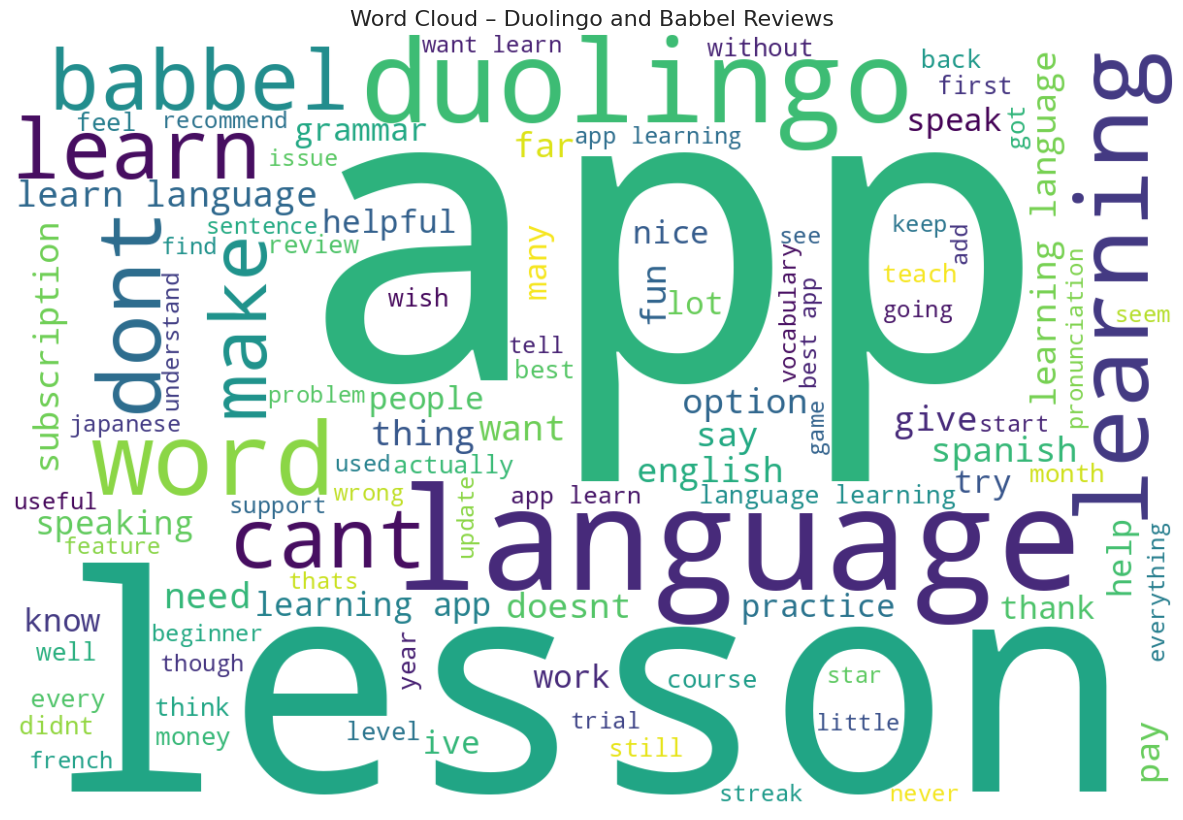

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("--- Word Cloud for All Duolingo and Babbel Reviews ---")

# Concatenate all text from the 'Clean_Text_WC' column
all_reviews_text = ' '.join(df['Clean_Text_WC'])

# Create the word cloud object
wordcloud = WordCloud(
    background_color='white',
    max_words=100,
    width=1200,
    height=800
).generate(all_reviews_text)

# Display the generated image:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud – Duolingo and Babbel Reviews', fontsize=16)
plt.axis('off') # Do not show axes for a cleaner look
plt.tight_layout(pad=0)
plt.show()


Number of Duolingo reviews used for word cloud: 1270


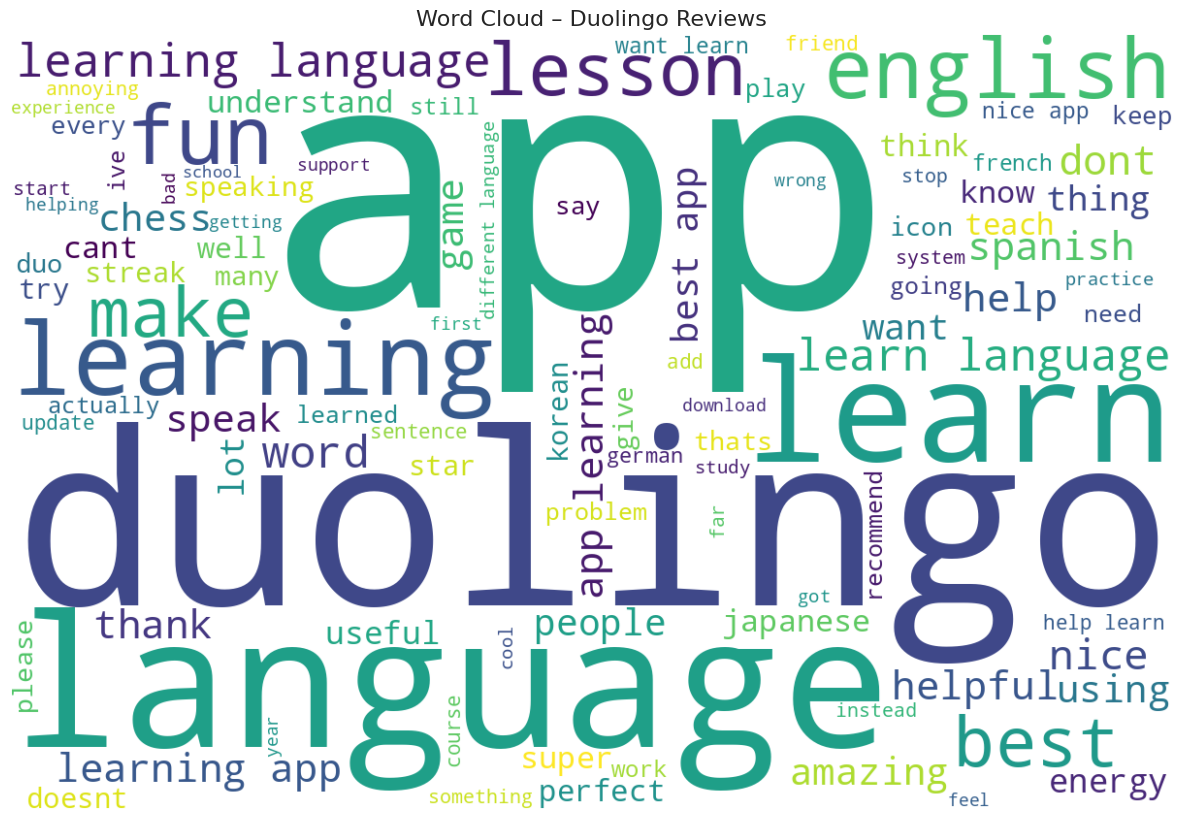


Number of Babbel reviews used for word cloud: 1754


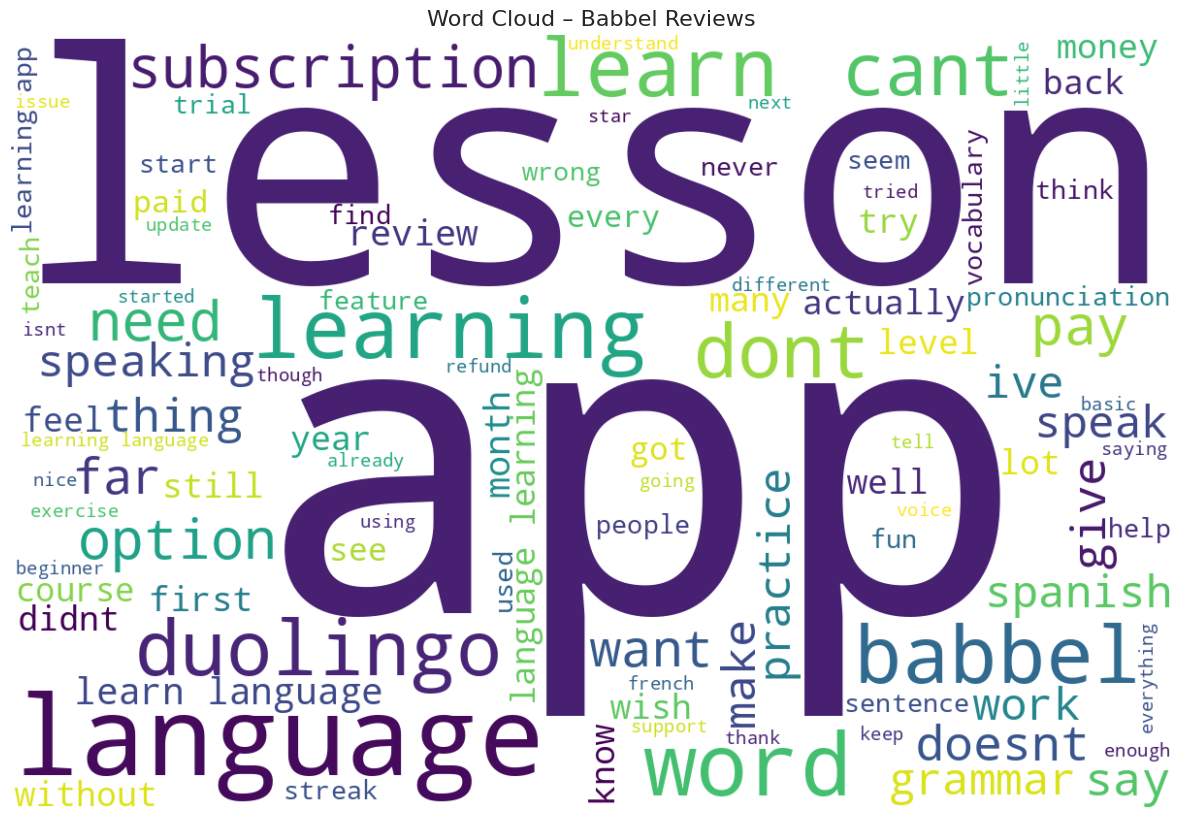

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter data for Duolingo and Babbel
df_duolingo_wc = df[df['app'] == 'Duolingo']['Clean_Text_WC']
df_babbel_wc = df[df['app'] == 'Babbel']['Clean_Text_WC']

# Concatenate text for each app
duolingo_text = ' '.join(df_duolingo_wc)
babbel_text = ' '.join(df_babbel_wc)

# WordCloud settings (consistent for both for meaningful comparison)
wc_settings = {
    'background_color': 'white',
    'max_words': 100,
    'width': 1200,
    'height': 800,
    'random_state': 42 # for reproducibility
}

# --- Duolingo Word Cloud ---
print(f"\nNumber of Duolingo reviews used for word cloud: {len(df_duolingo_wc)}")
wordcloud_duolingo = WordCloud(**wc_settings).generate(duolingo_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_duolingo, interpolation='bilinear')
plt.title('Word Cloud – Duolingo Reviews', fontsize=16)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# --- Babbel Word Cloud ---
print(f"\nNumber of Babbel reviews used for word cloud: {len(df_babbel_wc)}")
wordcloud_babbel = WordCloud(**wc_settings).generate(babbel_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_babbel, interpolation='bilinear')
plt.title('Word Cloud – Babbel Reviews', fontsize=16)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


--- Word Clouds by Overall Rating Sentiment ---

Number of overall Positive reviews: 1795


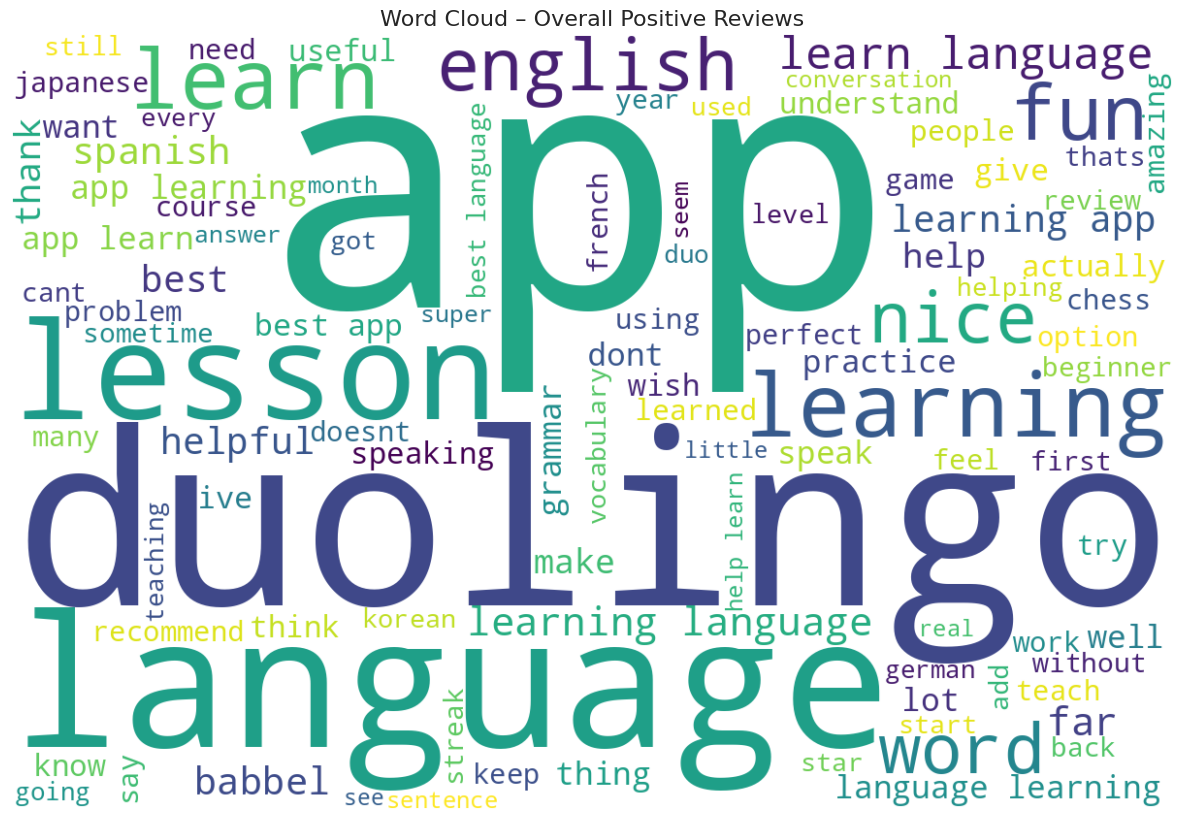


Number of overall Neutral reviews: 266


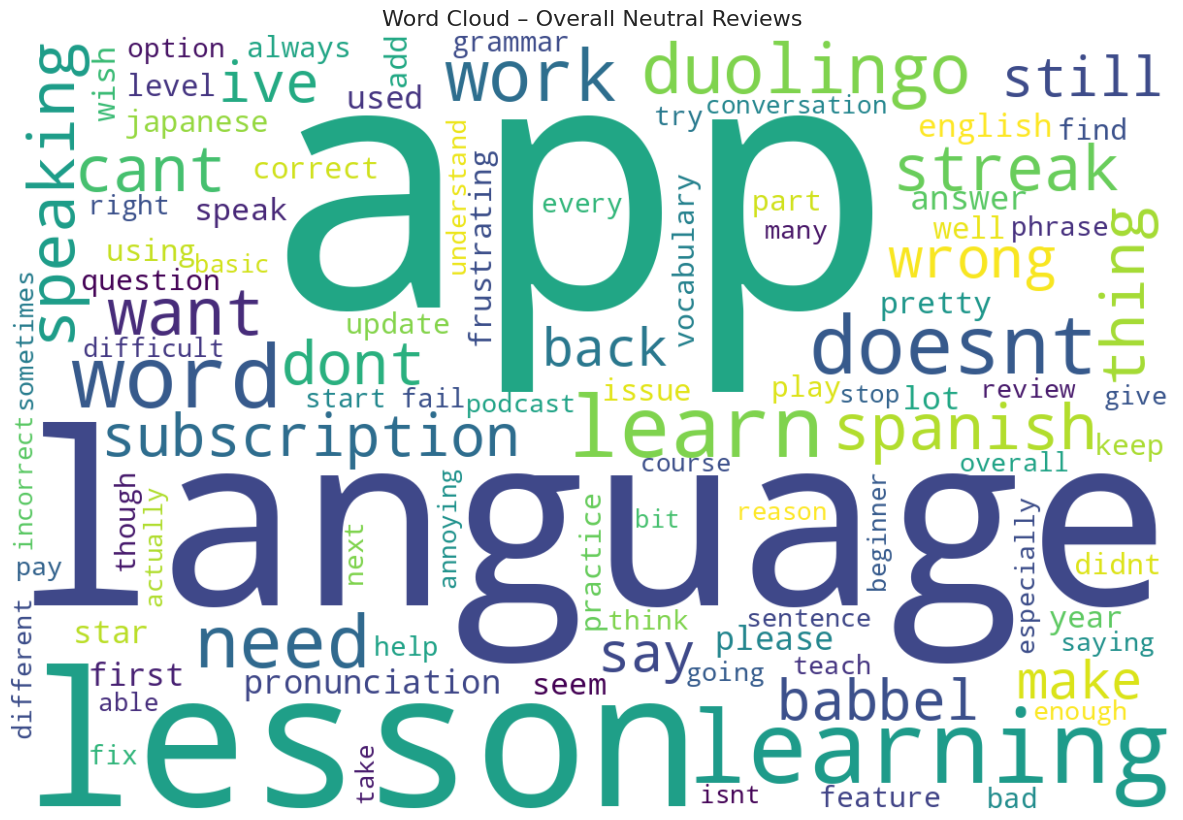


Number of overall Negative reviews: 963


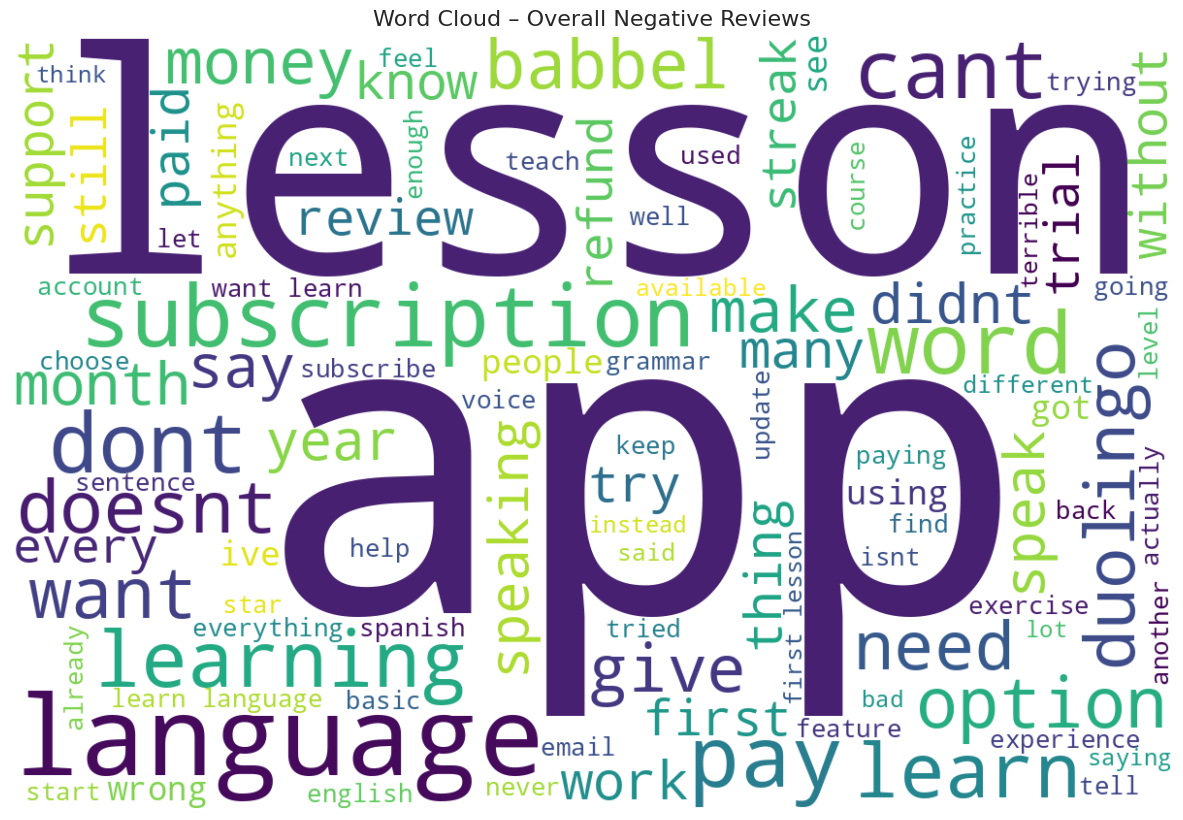


--- Word Clouds by App and Rating Sentiment (Positive & Negative) ---

Number of Duolingo Positive reviews: 1048


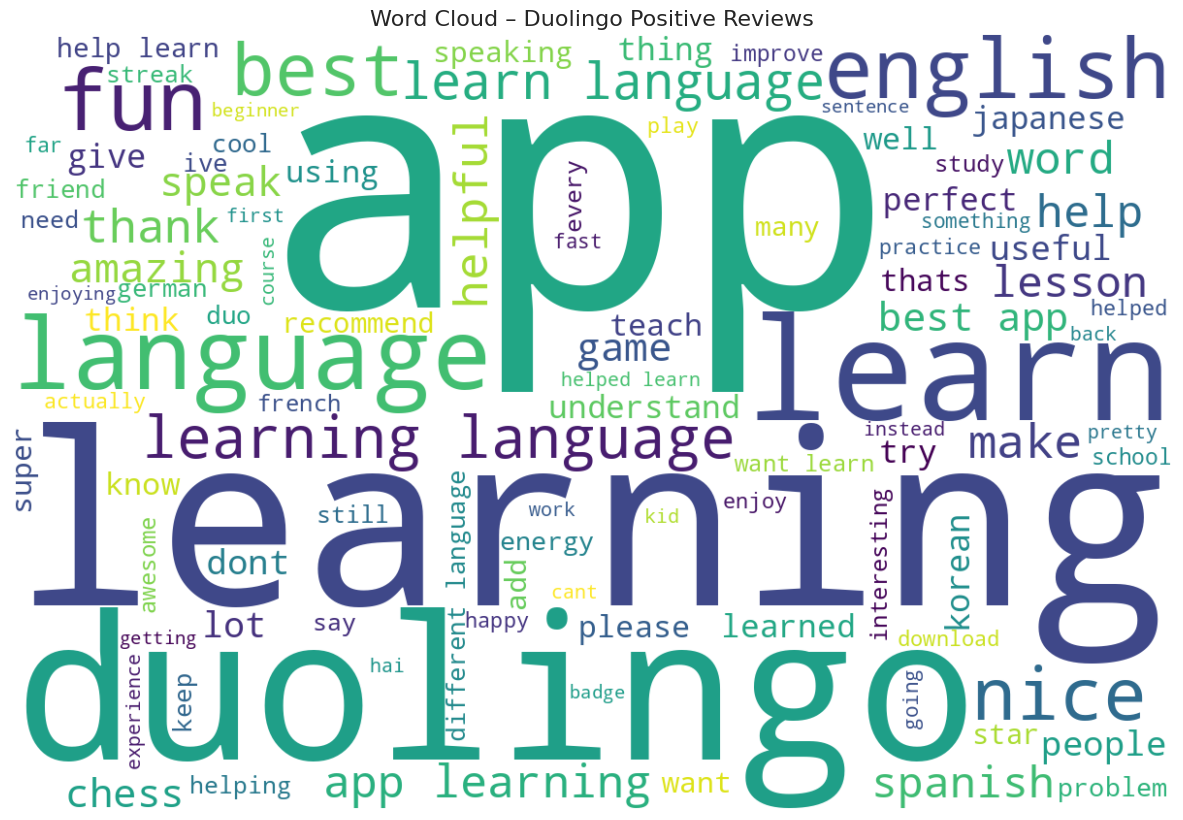


Number of Duolingo Negative reviews: 163


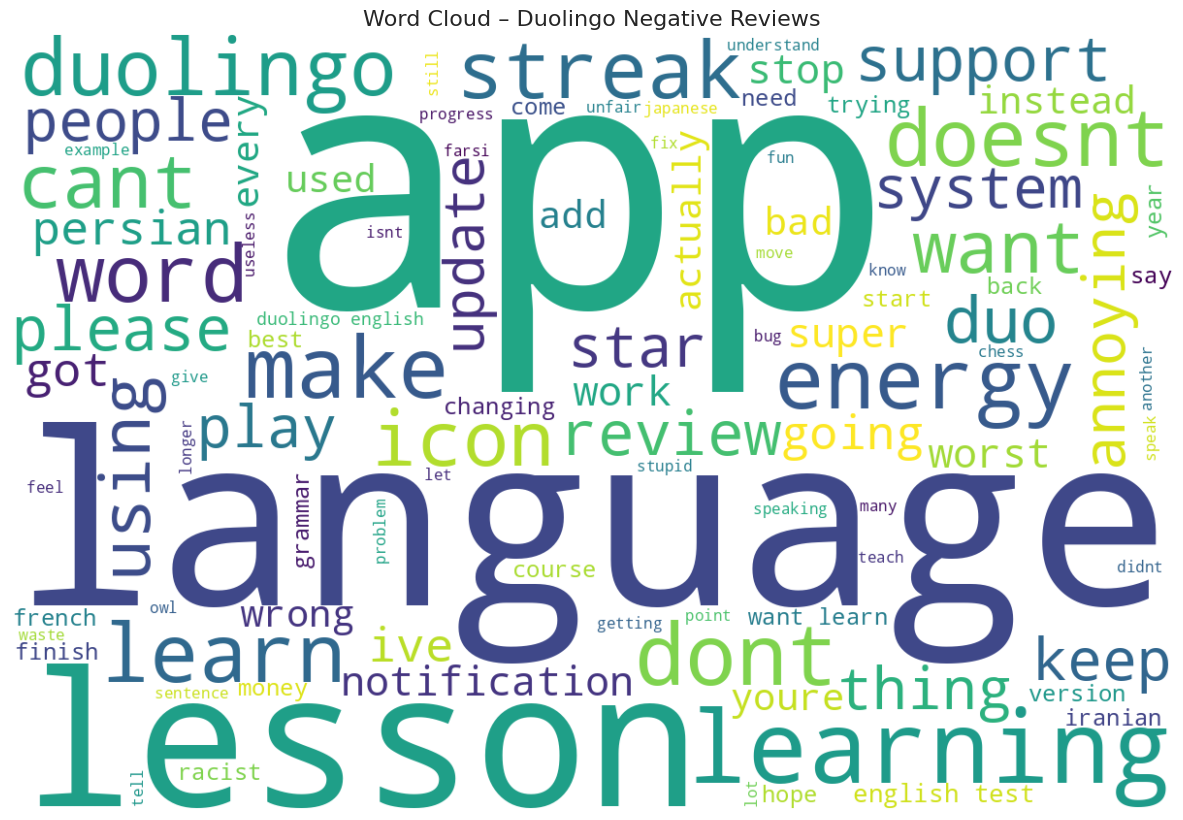


Number of Babbel Positive reviews: 747


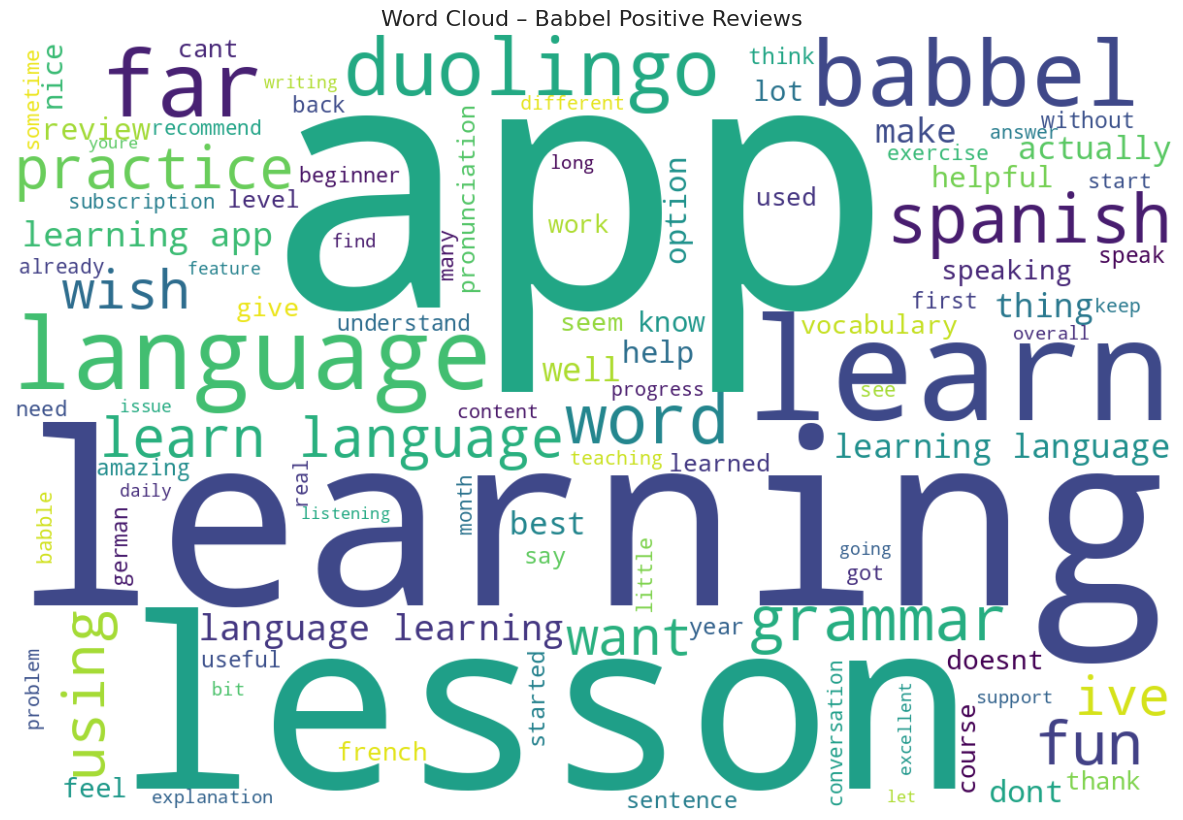


Number of Babbel Negative reviews: 800


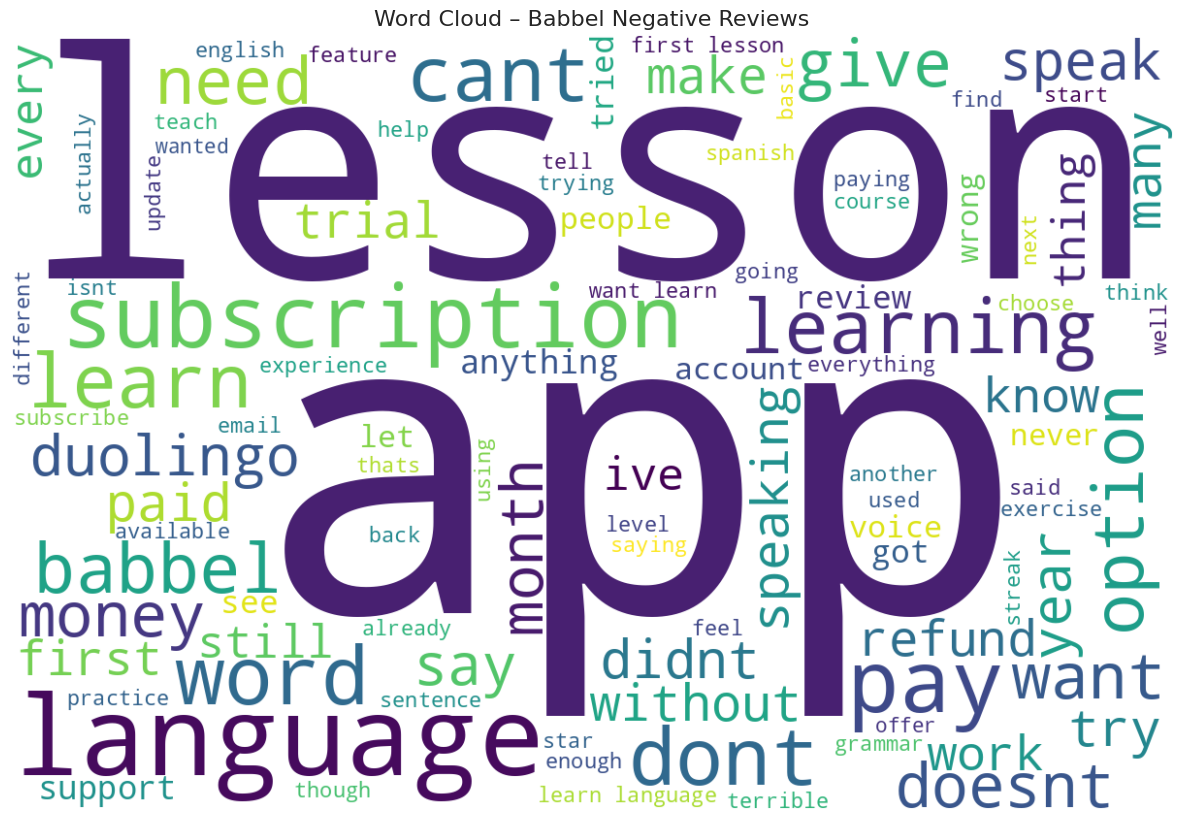

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Define common WordCloud settings for consistency
wc_settings = {
    'background_color': 'white',
    'max_words': 100,
    'width': 1200,
    'height': 800,
    'random_state': 42 # for reproducibility
}

MIN_TEXT_LENGTH = 100 # Minimum characters required to generate a word cloud

print("--- Word Clouds by Overall Rating Sentiment ---")

sentiment_categories = ['Positive', 'Neutral', 'Negative']

# Generate word clouds for overall sentiment categories
for sentiment in sentiment_categories:
    sentiment_df = df[df['Rating_Sentiment'] == sentiment]
    num_reviews = len(sentiment_df)
    sentiment_text = ' '.join(sentiment_df['Clean_Text_WC'])

    print(f"\nNumber of overall {sentiment} reviews: {num_reviews}")

    if len(sentiment_text) > MIN_TEXT_LENGTH:
        wordcloud = WordCloud(**wc_settings).generate(sentiment_text)
        plt.figure(figsize=(12, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud – Overall {sentiment} Reviews', fontsize=16)
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.show()
    else:
        print(f"Insufficient text to generate a word cloud for overall {sentiment} reviews.")

print("\n--- Word Clouds by App and Rating Sentiment (Positive & Negative) ---")

app_names = ['Duolingo', 'Babbel']
# Focus on Positive and Negative for app-specific comparison as requested
app_sentiment_categories = ['Positive', 'Negative']

# Generate word clouds for each app by focused sentiment categories
for app_name in app_names:
    for sentiment in app_sentiment_categories:
        app_sentiment_df = df[(df['app'] == app_name) & (df['Rating_Sentiment'] == sentiment)]
        num_reviews = len(app_sentiment_df)
        app_sentiment_text = ' '.join(app_sentiment_df['Clean_Text_WC'])

        print(f"\nNumber of {app_name} {sentiment} reviews: {num_reviews}")

        if len(app_sentiment_text) > MIN_TEXT_LENGTH:
            wordcloud = WordCloud(**wc_settings).generate(app_sentiment_text)
            plt.figure(figsize=(12, 8))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(f'Word Cloud – {app_name} {sentiment} Reviews', fontsize=16)
            plt.axis('off')
            plt.tight_layout(pad=0)
            plt.show()
        else:
            print(f"Insufficient text to generate a word cloud for {app_name} {sentiment} reviews.")


In [20]:
from collections import Counter
import pandas as pd

def get_top_words_by_sentiment(dataframe, sentiment, app_name=None, top_n=15):
    """
    Returns a DataFrame of the top_n most frequent words for a given sentiment
    and optionally for a specific app, using the 'Clean_Text_WC' column.
    """
    # Filter by sentiment
    filtered_df = dataframe[dataframe['Rating_Sentiment'] == sentiment]

    # Further filter by app if app_name is provided
    if app_name:
        filtered_df = filtered_df[filtered_df['app'] == app_name]

    # Concatenate all cleaned text into a single string
    all_words_text = ' '.join(filtered_df['Clean_Text_WC'])

    # Tokenize the text and count word frequencies
    words = all_words_text.split()
    word_counts = Counter(words)

    # Get the top_n most common words
    top_words_data = word_counts.most_common(top_n)

    # Create a DataFrame
    result_df = pd.DataFrame(top_words_data, columns=['Word', 'Frequency'])
    return result_df


print("--- Top 15 Most Frequent Words by Overall Rating Sentiment ---")

# Overall Positive reviews
print("\nTop 15 Words in Overall Positive Reviews:")
positive_words_overall = get_top_words_by_sentiment(df, 'Positive')
print(positive_words_overall.to_markdown(index=False))

# Overall Neutral reviews
print("\nTop 15 Words in Overall Neutral Reviews:")
neutral_words_overall = get_top_words_by_sentiment(df, 'Neutral')
print(neutral_words_overall.to_markdown(index=False))

# Overall Negative reviews
print("\nTop 15 Words in Overall Negative Reviews:")
negative_words_overall = get_top_words_by_sentiment(df, 'Negative')
print(negative_words_overall.to_markdown(index=False))


print("\n--- Top 15 Most Frequent Words by App and Rating Sentiment (Positive & Negative) ---")

# Duolingo Positive reviews
print("\nTop 15 Words in Duolingo Positive Reviews:")
duolingo_positive_words = get_top_words_by_sentiment(df, 'Positive', 'Duolingo')
print(duolingo_positive_words.to_markdown(index=False))

# Duolingo Negative reviews
print("\nTop 15 Words in Duolingo Negative Reviews:")
duolingo_negative_words = get_top_words_by_sentiment(df, 'Negative', 'Duolingo')
print(duolingo_negative_words.to_markdown(index=False))

# Babbel Positive reviews
print("\nTop 15 Words in Babbel Positive Reviews:")
babbel_positive_words = get_top_words_by_sentiment(df, 'Positive', 'Babbel')
print(babbel_positive_words.to_markdown(index=False))

# Babbel Negative reviews
print("\nTop 15 Words in Babbel Negative Reviews:")
babbel_negative_words = get_top_words_by_sentiment(df, 'Negative', 'Babbel')
print(babbel_negative_words.to_markdown(index=False))


--- Top 15 Most Frequent Words by Overall Rating Sentiment ---

Top 15 Words in Overall Positive Reviews:
| Word     |   Frequency |
|:---------|------------:|
| app      |         703 |
| learning |         484 |
| language |         468 |
| learn    |         375 |
| duolingo |         232 |
| lesson   |         161 |
| best     |         146 |
| not      |         142 |
| fun      |         135 |
| english  |         102 |
| word     |          99 |
| spanish  |          98 |
| nice     |          96 |
| help     |          95 |
| far      |          90 |

Top 15 Words in Overall Neutral Reviews:
| Word     |   Frequency |
|:---------|------------:|
| app      |         153 |
| language |         110 |
| not      |          78 |
| lesson   |          74 |
| learning |          60 |
| word     |          57 |
| learn    |          42 |
| doesnt   |          37 |
| need     |          30 |
| speaking |          30 |
| work     |          29 |
| duolingo |          27 |
| also     |   

--- Trigram Frequency Analysis ---

Overall Top 20 Trigrams (from Clean_Text):
| term                         |   frequency |
|:-----------------------------|------------:|
| learning new language        |          36 |
| language learning app        |          36 |
| learn new language           |          33 |
| app learning language        |          29 |
| app learn language           |          18 |
| best language learning       |          17 |
| good app learning            |          15 |
| best app learning            |          13 |
| great app learning           |          13 |
| much better duolingo         |          10 |
| language want learn          |           9 |
| great learning app           |           9 |
| best app learn               |           9 |
| want learn language          |           8 |
| best learning app            |           8 |
| bought lifetime subscription |           8 |
| learning different language  |           8 |
| app help learn            

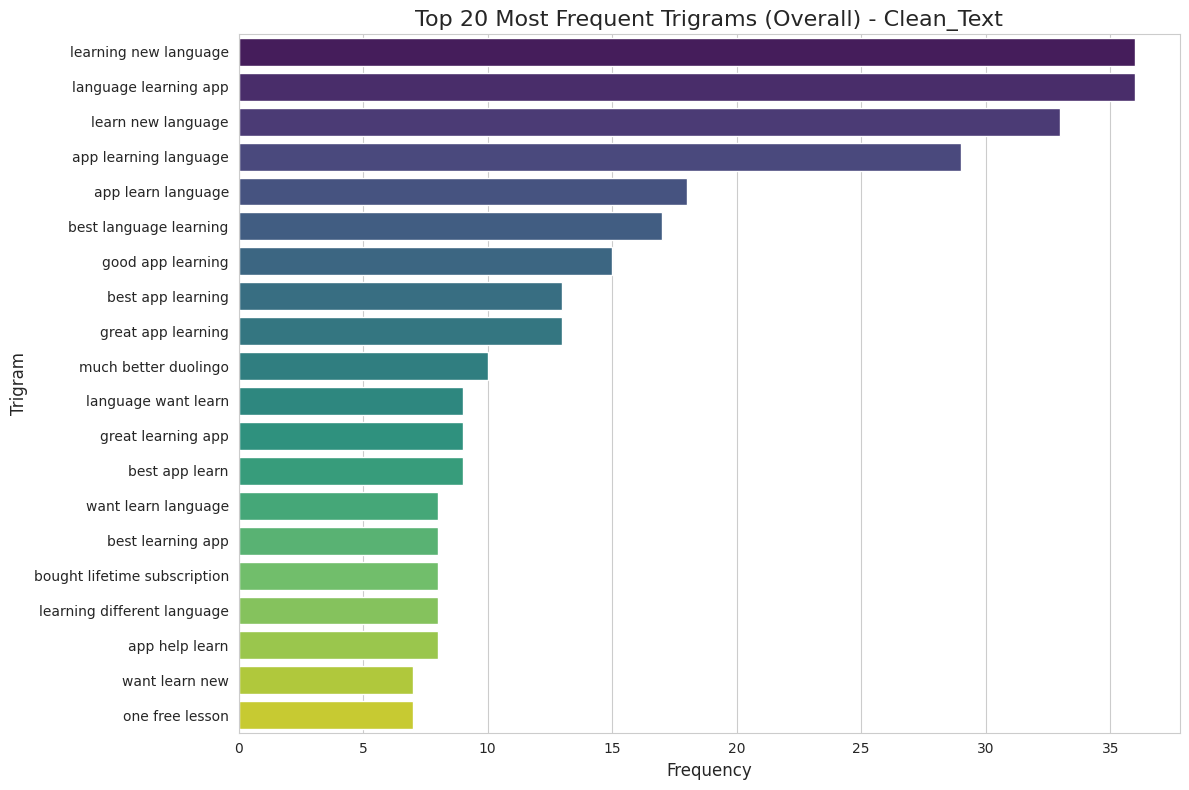


Duolingo Top 15 Trigrams (from Clean_Text):
| term                        |   frequency |
|:----------------------------|------------:|
| learning new language       |          23 |
| app learning language       |          22 |
| learn new language          |          17 |
| language learning app       |          12 |
| good app learning           |          11 |
| best app learning           |          10 |
| app learn language          |           8 |
| great app learning          |           8 |
| best app learn              |           7 |
| learning different language |           7 |
| best learning app           |           7 |
| best language learning      |           7 |
| duolingo english test       |           6 |
| want learn new              |           6 |
| app learning new            |           5 |


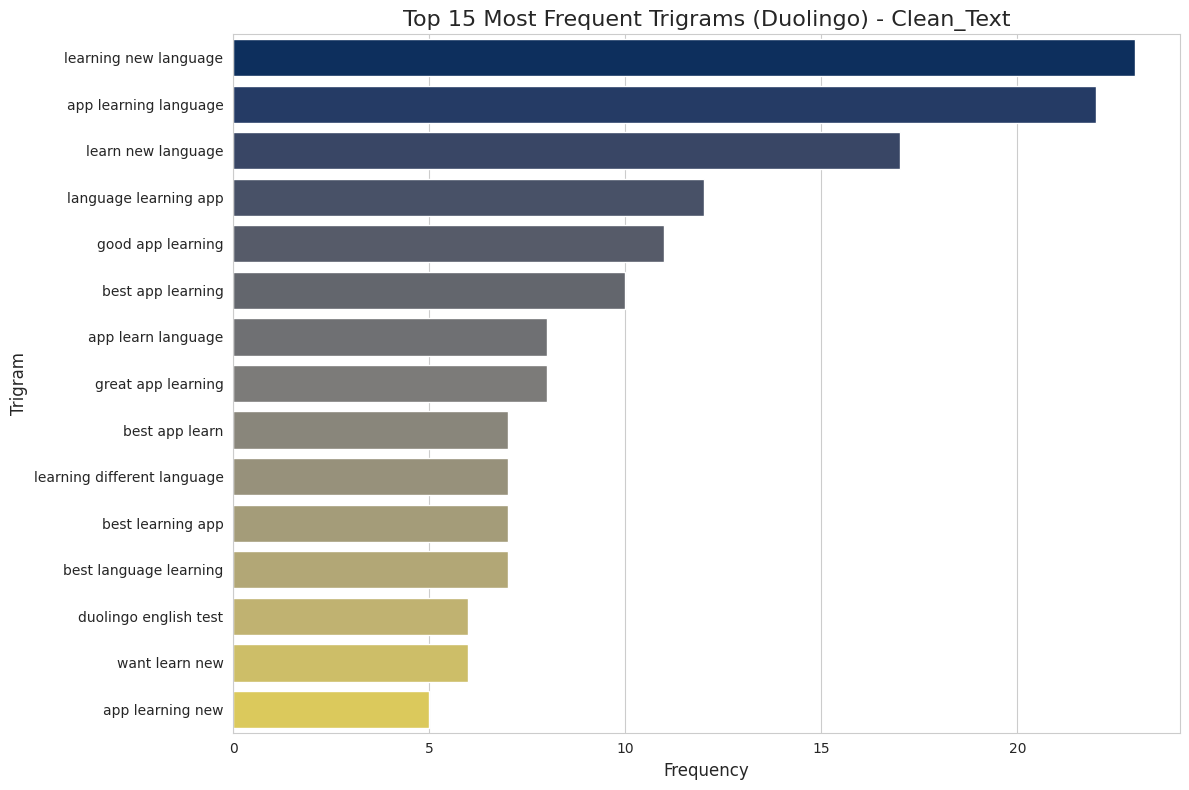


Babbel Top 15 Trigrams (from Clean_Text):
| term                         |   frequency |
|:-----------------------------|------------:|
| language learning app        |          24 |
| learn new language           |          16 |
| learning new language        |          13 |
| best language learning       |          10 |
| app learn language           |          10 |
| much better duolingo         |          10 |
| bought lifetime subscription |           8 |
| app learning language        |           7 |
| one free lesson              |           7 |
| get money back               |           6 |
| first lesson free            |           6 |
| language learning apps       |           6 |
| cant get past                |           6 |
| language want learn          |           6 |
| language wanted learn        |           6 |


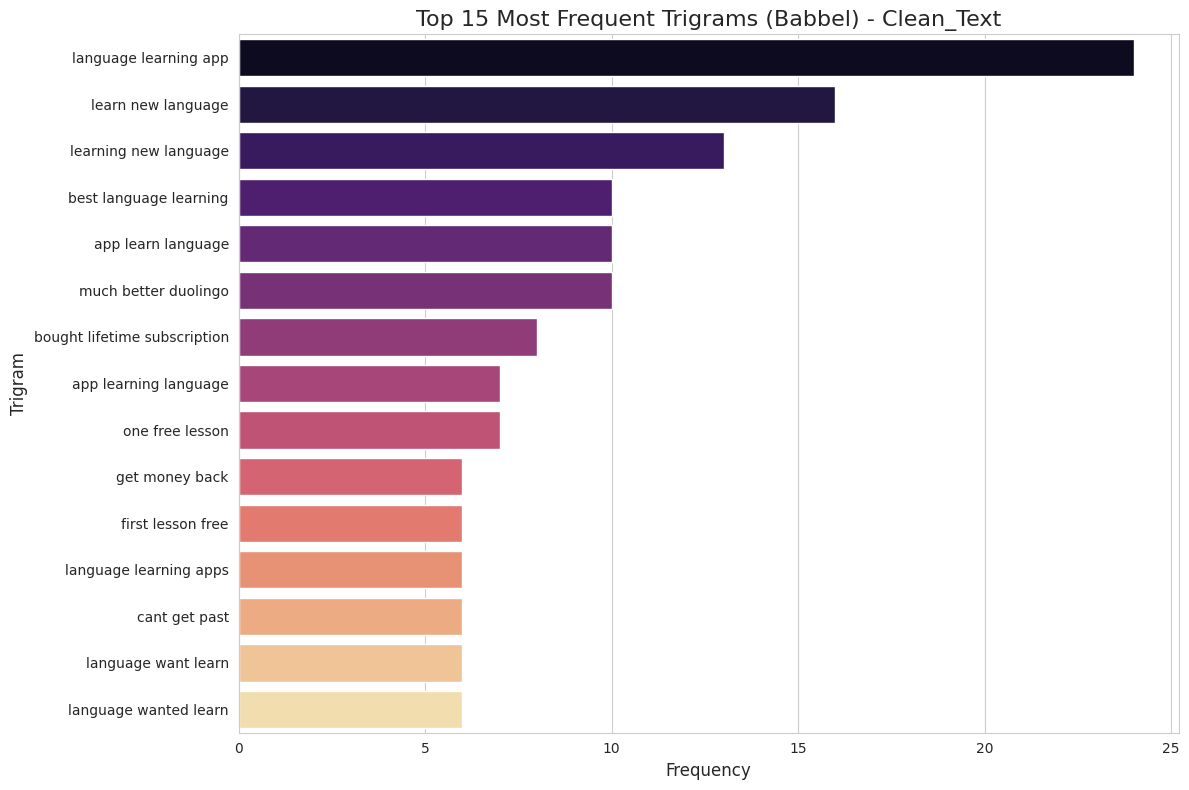

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Trigram Frequency Analysis ---")

# Helper function to get top N-grams
def get_top_ngrams(text_series, ngram_range=(3,3), top_n=20, max_features=5000, min_df=3):
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()
    sums = X.sum(axis=0)
    freq_df = pd.DataFrame({'term': feature_names, 'frequency': sums.tolist()[0]})
    return freq_df.sort_values(by='frequency', ascending=False).head(top_n)

# --- 1. Overall Top 20 Trigrams ---
print("\nOverall Top 20 Trigrams (from Clean_Text):")
overall_top_trigrams = get_top_ngrams(df['Clean_Text'], ngram_range=(3,3), top_n=20)
print(overall_top_trigrams.to_markdown(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(x='frequency', y='term', hue='term', data=overall_top_trigrams, palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Trigrams (Overall) - Clean_Text', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Trigram', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Duolingo Top 15 Trigrams ---
df_duolingo = df[df['app'] == 'Duolingo']
print("\nDuolingo Top 15 Trigrams (from Clean_Text):")
duolingo_top_trigrams = get_top_ngrams(df_duolingo['Clean_Text'], ngram_range=(3,3), top_n=15)
print(duolingo_top_trigrams.to_markdown(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(x='frequency', y='term', hue='term', data=duolingo_top_trigrams, palette='cividis', legend=False)
plt.title('Top 15 Most Frequent Trigrams (Duolingo) - Clean_Text', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Trigram', fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. Babbel Top 15 Trigrams ---
df_babbel = df[df['app'] == 'Babbel']
print("\nBabbel Top 15 Trigrams (from Clean_Text):")
babbel_top_trigrams = get_top_ngrams(df_babbel['Clean_Text'], ngram_range=(3,3), top_n=15)
print(babbel_top_trigrams.to_markdown(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(x='frequency', y='term', hue='term', data=babbel_top_trigrams, palette='magma', legend=False)
plt.title('Top 15 Most Frequent Trigrams (Babbel) - Clean_Text', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Trigram', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

print("--- Trigram TF-IDF Analysis ---")

# Explanation: Simple frequency (like in CountVectorizer) identifies commonly repeated phrases.
# TF-IDF (Term Frequency-Inverse Document Frequency) identifies phrases that are
# relatively distinctive within the review corpus. A high TF-IDF score means a term is
# frequent within a document (or a set of documents like 'Duolingo reviews') but rare
# across all documents, making it a good indicator of importance or distinctiveness.

# --- 1. Overall Top 15 Trigrams by Mean TF-IDF ---
print("\nOverall Top 15 Trigrams by Mean TF-IDF (from Clean_Text):")

# Combine feature names and mean TF-IDF scores into a DataFrame
overall_tfidf_df = pd.DataFrame({
    'Term': feature_names,
    'Mean_TFIDF': mean_tfidf_scores
})

# Filter for trigrams (terms with two spaces)
overall_trigram_tfidf_df = overall_tfidf_df[overall_tfidf_df['Term'].apply(lambda x: len(x.split()) == 3)].copy()
overall_trigram_tfidf_df.rename(columns={'Term': 'Trigram'}, inplace=True)

# Sort and display the top 15 trigrams
overall_trigram_tfidf_df = overall_trigram_tfidf_df.sort_values(by='Mean_TFIDF', ascending=False).head(15)
print(overall_trigram_tfidf_df.to_markdown(index=False))

# --- 2. Duolingo Top 15 Trigrams by Mean TF-IDF ---
print("\nDuolingo Top 15 Trigrams by Mean TF-IDF (from Clean_Text):")

# Combine feature names and mean TF-IDF scores for Duolingo into a DataFrame
duolingo_tfidf_df = pd.DataFrame({
    'Term': feature_names_duolingo,
    'Mean_TFIDF': mean_tfidf_scores_duolingo
})

# Filter for trigrams
duolingo_trigram_tfidf_df = duolingo_tfidf_df[duolingo_tfidf_df['Term'].apply(lambda x: len(x.split()) == 3)].copy()
duolingo_trigram_tfidf_df.rename(columns={'Term': 'Trigram'}, inplace=True)

# Sort and display the top 15 trigrams
duolingo_trigram_tfidf_df = duolingo_trigram_tfidf_df.sort_values(by='Mean_TFIDF', ascending=False).head(15)
print(duolingo_trigram_tfidf_df.to_markdown(index=False))

# --- 3. Babbel Top 15 Trigrams by Mean TF-IDF ---
print("\nBabbel Top 15 Trigrams by Mean TF-IDF (from Clean_Text):")

# Combine feature names and mean TF-IDF scores for Babbel into a DataFrame
babbel_tfidf_df = pd.DataFrame({
    'Term': feature_names_babbel,
    'Mean_TFIDF': mean_tfidf_scores_babbel
})

# Filter for trigrams
babbel_trigram_tfidf_df = babbel_tfidf_df[babbel_tfidf_df['Term'].apply(lambda x: len(x.split()) == 3)].copy()
babbel_trigram_tfidf_df.rename(columns={'Term': 'Trigram'}, inplace=True)

# Sort and display the top 15 trigrams
babbel_trigram_tfidf_df = babbel_trigram_tfidf_df.sort_values(by='Mean_TFIDF', ascending=False).head(15)
print(babbel_trigram_tfidf_df.to_markdown(index=False))


--- Trigram TF-IDF Analysis ---

Overall Top 15 Trigrams by Mean TF-IDF (from Clean_Text):
| Trigram                     |   Mean_TFIDF |
|:----------------------------|-------------:|
| learning new language       |  0.00363574  |
| app learning language       |  0.00324784  |
| learn new language          |  0.00294485  |
| language learning app       |  0.00290362  |
| good app learning           |  0.00212064  |
| app learn language          |  0.00204606  |
| best language learning      |  0.00169792  |
| great app learning          |  0.00162886  |
| best app learning           |  0.00153911  |
| much better duolingo        |  0.00124084  |
| best app learn              |  0.00121222  |
| good learning app           |  0.00111946  |
| best learning app           |  0.00107277  |
| great learning app          |  0.00105493  |
| learning different language |  0.000985177 |

Duolingo Top 15 Trigrams by Mean TF-IDF (from Clean_Text):
| Trigram                     |   Mean_TFIDF |
|:-

--- VADER Sentiment Analysis ---

1. Overall VADER Sentiment Distribution:
| VADER_Sentiment   |   Count |   Percentage |
|:------------------|--------:|-------------:|
| Positive          |    2043 |        67.56 |
| Negative          |     645 |        21.33 |
| Neutral           |     336 |        11.11 |

2. Duolingo VADER Sentiment Distribution:
| VADER_Sentiment   |   Count |   Percentage |
|:------------------|--------:|-------------:|
| Positive          |    1010 |        79.53 |
| Negative          |     147 |        11.57 |
| Neutral           |     113 |         8.9  |

3. Babbel VADER Sentiment Distribution:
| VADER_Sentiment   |   Count |   Percentage |
|:------------------|--------:|-------------:|
| Positive          |    1033 |        58.89 |
| Negative          |     498 |        28.39 |
| Neutral           |     223 |        12.71 |

4. Average VADER Compound Score by App:
| app      | VADER_Compound   |
|:---------|:-----------------|
| Babbel   | 0.2052           |

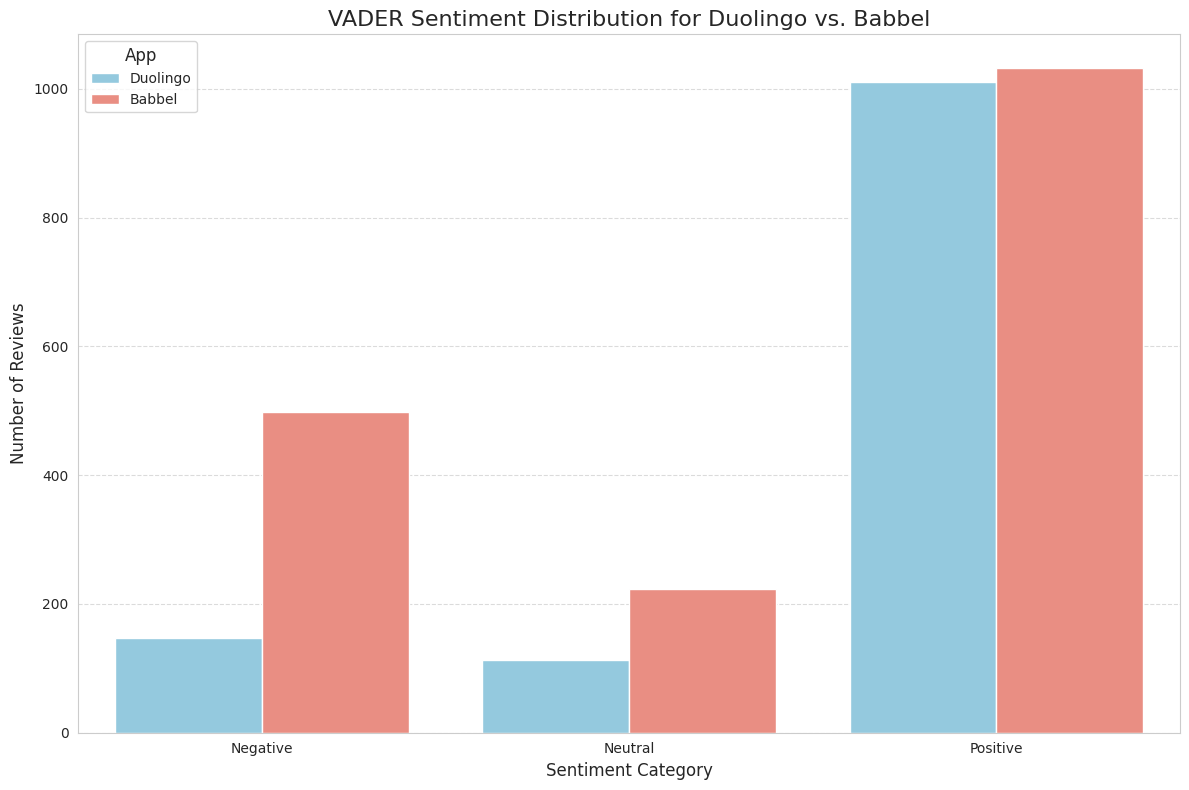

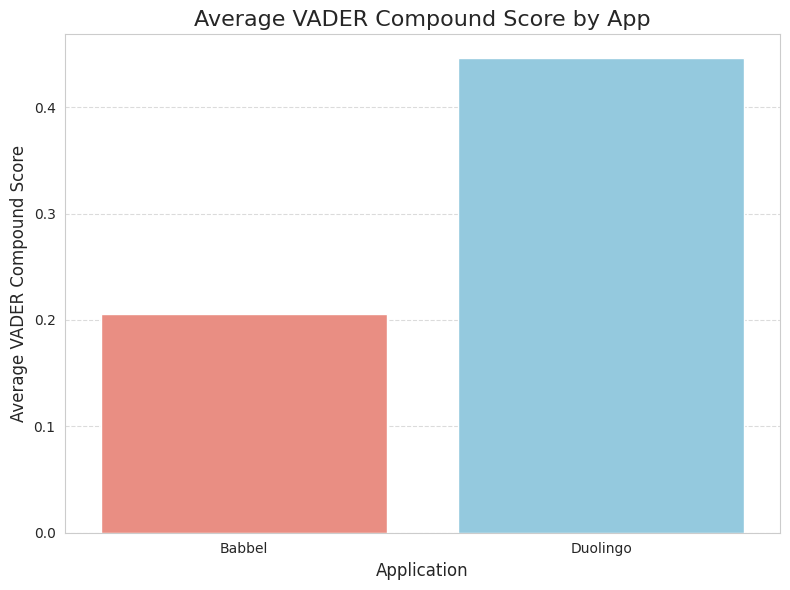

In [23]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- VADER Sentiment Analysis ---")

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Calculate VADER compound score for each review using the original 'content' column
df['VADER_Compound'] = df['content'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Classify VADER compound scores into sentiment categories
def get_vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['VADER_Sentiment'] = df['VADER_Compound'].apply(get_vader_sentiment)

# 1. Display Overall VADER sentiment distribution
print("\n1. Overall VADER Sentiment Distribution:")
overall_vader_counts = df['VADER_Sentiment'].value_counts()
overall_vader_percentages = df['VADER_Sentiment'].value_counts(normalize=True) * 100
overall_vader_df = pd.DataFrame({
    'Count': overall_vader_counts,
    'Percentage': overall_vader_percentages
}).round(2)
print(overall_vader_df.to_markdown())

# 2. VADER sentiment distribution for Duolingo
df_duolingo = df[df['app'] == 'Duolingo']
print("\n2. Duolingo VADER Sentiment Distribution:")
duolingo_vader_counts = df_duolingo['VADER_Sentiment'].value_counts()
duolingo_vader_percentages = df_duolingo['VADER_Sentiment'].value_counts(normalize=True) * 100
duolingo_vader_df = pd.DataFrame({
    'Count': duolingo_vader_counts,
    'Percentage': duolingo_vader_percentages
}).round(2)
print(duolingo_vader_df.to_markdown())

# 3. VADER sentiment distribution for Babbel
df_babbel = df[df['app'] == 'Babbel']
print("\n3. Babbel VADER Sentiment Distribution:")
babbel_vader_counts = df_babbel['VADER_Sentiment'].value_counts()
babbel_vader_percentages = df_babbel['VADER_Sentiment'].value_counts(normalize=True) * 100
babbel_vader_df = pd.DataFrame({
    'Count': babbel_vader_counts,
    'Percentage': babbel_vader_percentages
}).round(2)
print(babbel_vader_df.to_markdown())

# 4. Average VADER compound score by app
print("\n4. Average VADER Compound Score by App:")
avg_compound_by_app = df.groupby('app')['VADER_Compound'].mean().round(4)
print(avg_compound_by_app.to_markdown(numalign="left", stralign="left"))

# Create appropriate visualizations comparing the two apps

# Grouped bar chart for VADER Sentiment Distribution by App
plt.figure(figsize=(12, 8))
sns.countplot(x='VADER_Sentiment', hue='app', data=df, palette={'Duolingo': 'skyblue', 'Babbel': 'salmon'}, order=['Negative', 'Neutral', 'Positive'])
plt.title('VADER Sentiment Distribution for Duolingo vs. Babbel', fontsize=16)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='App', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar chart for Average VADER Compound Score by App
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_compound_by_app.index, y=avg_compound_by_app.values, hue=avg_compound_by_app.index, palette={'Duolingo': 'skyblue', 'Babbel': 'salmon'}, legend=False)
plt.title('Average VADER Compound Score by App', fontsize=16)
plt.xlabel('Application', fontsize=12)
plt.ylabel('Average VADER Compound Score', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Sentiment Comparison: Rating-Based vs. Text-Based (VADER) ---

1. Overall Agreement between Rating-Based and VADER Sentiment: 68.12%

2. Overall Confusion Matrix (Rating-Based vs. VADER Sentiment):
| Rating Proxy (Rating_Sentiment)   |   Negative |   Neutral |   Positive |   All |
|:----------------------------------|-----------:|----------:|-----------:|------:|
| Negative                          |        460 |       171 |        332 |   963 |
| Neutral                           |         97 |        29 |        140 |   266 |
| Positive                          |         88 |       136 |       1571 |  1795 |
| All                               |        645 |       336 |       2043 |  3024 |


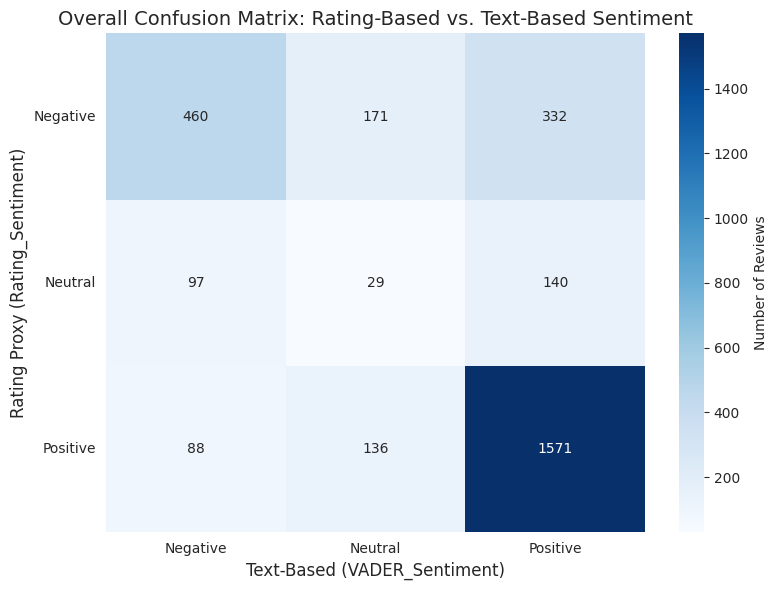


3. Agreement Percentage by App:
   Duolingo Agreement: 79.45%
   Babbel Agreement: 59.92%


/tmp/ipykernel_764/2001848446.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating_Sentiment', y='VADER_Compound', data=df,


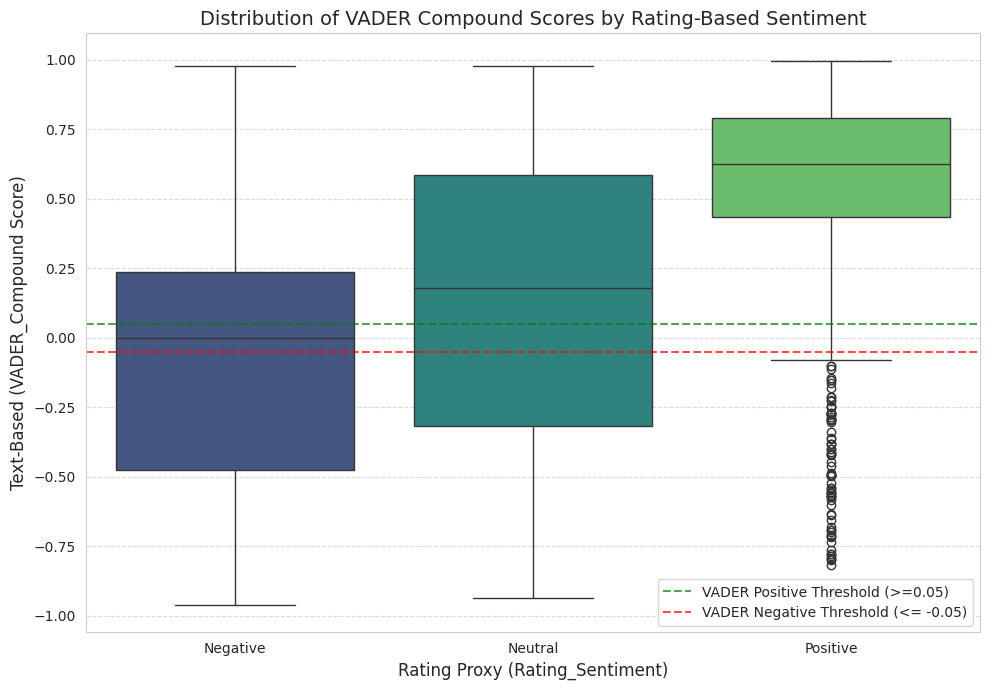


Note: Disagreements between sentiment methods are treated as mismatches, not necessarily sarcasm.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Sentiment Comparison: Rating-Based vs. Text-Based (VADER) ---")

# 1. Overall agreement percentage between the two methods
overall_agreement = (df['Rating_Sentiment'] == df['VADER_Sentiment']).mean() * 100
print(f"\n1. Overall Agreement between Rating-Based and VADER Sentiment: {overall_agreement:.2f}%")

# 2. A confusion matrix using pd.crosstab
print("\n2. Overall Confusion Matrix (Rating-Based vs. VADER Sentiment):")
overall_confusion_matrix = pd.crosstab(df['Rating_Sentiment'], df['VADER_Sentiment'],
                                        rownames=['Rating Proxy (Rating_Sentiment)'],
                                        colnames=['Text-Based (VADER_Sentiment)'],
                                        margins=True) # Add row/column sums
print(overall_confusion_matrix.to_markdown())

# Create a heatmap of the overall confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(overall_confusion_matrix.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Number of Reviews'})
plt.title('Overall Confusion Matrix: Rating-Based vs. Text-Based Sentiment', fontsize=14)
plt.xlabel('Text-Based (VADER_Sentiment)', fontsize=12)
plt.ylabel('Rating Proxy (Rating_Sentiment)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# 3. Agreement percentage separately for Duolingo and Babbel
print("\n3. Agreement Percentage by App:")
for app_name in ['Duolingo', 'Babbel']:
    app_df = df[df['app'] == app_name]
    app_agreement = (app_df['Rating_Sentiment'] == app_df['VADER_Sentiment']).mean() * 100
    print(f"   {app_name} Agreement: {app_agreement:.2f}%")

# Create a boxplot showing the distribution of VADER compound scores
# across Positive, Neutral and Negative rating-based sentiment categories.
plt.figure(figsize=(10, 7))
sns.boxplot(x='Rating_Sentiment', y='VADER_Compound', data=df,
            order=['Negative', 'Neutral', 'Positive'], palette='viridis')
plt.title('Distribution of VADER Compound Scores by Rating-Based Sentiment', fontsize=14)
plt.xlabel('Rating Proxy (Rating_Sentiment)', fontsize=12)
plt.ylabel('Text-Based (VADER_Compound Score)', fontsize=12)
plt.axhline(0.05, color='green', linestyle='--', alpha=0.7, label='VADER Positive Threshold (>=0.05)')
plt.axhline(-0.05, color='red', linestyle='--', alpha=0.7, label='VADER Negative Threshold (<= -0.05)')
plt.legend()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nNote: Disagreements between sentiment methods are treated as mismatches, not necessarily sarcasm.")


In [25]:
import pandas as pd
import numpy as np

# Set a fixed random state for reproducibility
RANDOM_STATE = 42

# Columns to display for the examples
DISPLAY_COLUMNS = ['app', 'rating', 'VADER_Compound', 'VADER_Sentiment', 'Rating_Sentiment', 'content']

print("--- Reviews with Sentiment Disagreements ---")

# 1. Positive VADER Sentiment but Negative Rating Sentiment
print("\n1. Reviews where VADER Sentiment is Positive but Rating Sentiment is Negative:")
positive_vader_negative_rating = df[
    (df['VADER_Sentiment'] == 'Positive') &
    (df['Rating_Sentiment'] == 'Negative')
]

if not positive_vader_negative_rating.empty:
    display(positive_vader_negative_rating[DISPLAY_COLUMNS].sample(min(10, len(positive_vader_negative_rating)), random_state=RANDOM_STATE))
else:
    print("No reviews found with Positive VADER Sentiment and Negative Rating Sentiment.")

# 2. Negative VADER Sentiment but Positive Rating Sentiment
print("\n2. Reviews where VADER Sentiment is Negative but Rating Sentiment is Positive:")
negative_vader_positive_rating = df[
    (df['VADER_Sentiment'] == 'Negative') &
    (df['Rating_Sentiment'] == 'Positive')
]

if not negative_vader_positive_rating.empty:
    display(negative_vader_positive_rating[DISPLAY_COLUMNS].sample(min(10, len(negative_vader_positive_rating)), random_state=RANDOM_STATE))
else:
    print("No reviews found with Negative VADER Sentiment and Positive Rating Sentiment.")

print("\n-- Interpretation --")
print("Disagreements between rating-based sentiment and VADER text sentiment often highlight reviews that warrant closer manual examination. These cases are potential indicators of nuances that automated systems might miss, such as sarcasm, subtle irony, or a discrepancy between a user's overall experience (rating) and the specific words used in their review (text sentiment). It is important to treat these as candidate cases for deeper qualitative analysis rather than automatically assuming sarcasm or an error in the sentiment classification.")


--- Reviews with Sentiment Disagreements ---

1. Reviews where VADER Sentiment is Positive but Rating Sentiment is Negative:


,app,rating,VADER_Compound,VADER_Sentiment,Rating_Sentiment,content
482,Duolingo,2,0.1741,Positive,Negative,holy hell does it ever shove gamification down...
2920,Babbel,1,0.5267,Positive,Negative,"Nice app, disgusting pricing structure. Minimu..."
1366,Babbel,2,0.3724,Positive,Negative,I have no faults except it does didnt have any...
2116,Babbel,2,0.7321,Positive,Negative,"98% of lessons are locked behind a paywall, wh..."
1304,Babbel,1,0.5994,Positive,Negative,"""Hello."" ""How are you"" ""Good, thank you"". That..."
1938,Babbel,1,0.6908,Positive,Negative,does the thing where it wants you to sign up f...
2706,Babbel,2,0.7301,Positive,Negative,"besides there being no Irish, here is my early..."
2020,Babbel,2,0.7999,Positive,Negative,The guided conversations don't allow the micro...
2196,Babbel,1,0.1506,Positive,Negative,"Forcing me to give my voice to AI model, does ..."
2125,Babbel,1,0.6705,Positive,Negative,"Total waste of money, app is poorly designed a..."



2. Reviews where VADER Sentiment is Negative but Rating Sentiment is Positive:


,app,rating,VADER_Compound,VADER_Sentiment,Rating_Sentiment,content
2520,Babbel,5,-0.2960,Negative,Positive,I will be speaking Spanish in no time
19,Duolingo,4,-0.2500,Negative,Positive,theses days it's getting stuck why
762,Duolingo,4,-0.3032,Negative,Positive,I like this but i forgot to keep up my streak ...
700,Duolingo,5,-0.2732,Negative,Positive,it was fire💥 nice too
292,Duolingo,5,-0.2244,Negative,Positive,I forgot to do my Spanish lesson yesterday... ...
2069,Babbel,4,-0.2926,Negative,Positive,It works well but just started using it. Peopl...
206,Duolingo,5,-0.5563,Negative,Positive,Good app but microphone won't work please fix ...
561,Duolingo,4,-0.5588,Negative,Positive,"I love this app and the content is very good, ..."
75,Duolingo,4,-0.7993,Negative,Positive,it's bean a week and I have All ready learned ...
2126,Babbel,4,-0.2146,Negative,Positive,I under stand everything cant be Free but bro ...



-- Interpretation --
Disagreements between rating-based sentiment and VADER text sentiment often highlight reviews that warrant closer manual examination. These cases are potential indicators of nuances that automated systems might miss, such as sarcasm, subtle irony, or a discrepancy between a user's overall experience (rating) and the specific words used in their review (text sentiment). It is important to treat these as candidate cases for deeper qualitative analysis rather than automatically assuming sarcasm or an error in the sentiment classification.


In [26]:
import pandas as pd

# Initialize a dictionary to store comparison data
comparison_data = {}

# Iterate over each app to collect metrics
for app_name in ['Duolingo', 'Babbel']:
    app_df = df[df['app'] == app_name]

    # Calculate metrics
    num_reviews = len(app_df)
    avg_rating = app_df['rating'].mean()
    median_rating = app_df['rating'].median()
    perc_1_star = (app_df['rating'] == 1).mean() * 100
    perc_5_star = (app_df['rating'] == 5).mean() * 100

    # Rating-based sentiment percentages
    rating_sentiment_counts = app_df['Rating_Sentiment'].value_counts(normalize=True) * 100
    perc_rating_positive = rating_sentiment_counts.get('Positive', 0)
    perc_rating_neutral = rating_sentiment_counts.get('Neutral', 0)
    perc_rating_negative = rating_sentiment_counts.get('Negative', 0)

    # VADER sentiment percentages
    avg_vader_compound = app_df['VADER_Compound'].mean()
    vader_sentiment_counts = app_df['VADER_Sentiment'].value_counts(normalize=True) * 100
    perc_vader_positive = vader_sentiment_counts.get('Positive', 0)
    perc_vader_negative = vader_sentiment_counts.get('Negative', 0)

    # Sentiment-rating mismatch percentage
    # Recalculate agreement for current app for consistency and correctness
    agreement_percentage = (app_df['Rating_Sentiment'] == app_df['VADER_Sentiment']).mean() * 100
    mismatch_percentage = 100 - agreement_percentage

    # Store in dictionary
    comparison_data[app_name] = {
        'Number of Reviews': num_reviews,
        'Average Rating': avg_rating,
        'Median Rating': median_rating,
        'Percentage of 1-star reviews': perc_1_star,
        'Percentage of 5-star reviews': perc_5_star,
        'Percentage Rating Positive': perc_rating_positive,
        'Percentage Rating Neutral': perc_rating_neutral,
        'Percentage Rating Negative': perc_rating_negative,
        'Average VADER Compound Score': avg_vader_compound,
        'Percentage VADER Positive': perc_vader_positive,
        'Percentage VADER Negative': perc_vader_negative,
        'Sentiment-Rating Mismatch Percentage': mismatch_percentage
    }

# Create the comparison_summary DataFrame
comparison_summary = pd.DataFrame.from_dict(comparison_data, orient='index')

# Round numerical values for cleaner display
comparison_summary = comparison_summary.round(2)

# Rename columns for clarity as specified in the prompt
comparison_summary.columns = [
    'Number of Reviews',
    'Average Rating',
    'Median Rating',
    '1-star Reviews (%)',
    '5-star Reviews (%)',
    'Rating Positive (%)',
    'Rating Neutral (%)',
    'Rating Negative (%)',
    'Average VADER Compound Score',
    'VADER Positive (%)',
    'VADER Negative (%)',
    'Sentiment-Rating Mismatch (%)'
]

print("\n--- Comparative Summary Table for Duolingo and Babbel ---")
display(comparison_summary)



--- Comparative Summary Table for Duolingo and Babbel ---


,Number of Reviews,Average Rating,Median Rating,1-star Reviews (%),5-star Reviews (%),Rating Positive (%),Rating Neutral (%),Rating Negative (%),Average VADER Compound Score,VADER Positive (%),VADER Negative (%),Sentiment-Rating Mismatch (%)
Duolingo,1270,4.26,5.0,10.24,66.54,82.52,4.65,12.83,0.45,79.53,11.57,20.55
Babbel,1754,2.95,3.0,33.75,32.21,42.59,11.80,45.61,0.21,58.89,28.39,40.08


--- Analysis of Negative Reviews ---

### Duolingo Negative Reviews Analysis ###

Top 15 Unigrams in Duolingo Negative Reviews:
| term     |   frequency |
|:---------|------------:|
| app      |          92 |
| not      |          54 |
| language |          43 |
| lesson   |          36 |
| duolingo |          32 |
| learning |          29 |
| get      |          26 |
| learn    |          24 |
| make     |          24 |
| one      |          22 |
| want     |          20 |
| dont     |          20 |
| energy   |          19 |
| like     |          19 |
| time     |          18 |

Top 10 Trigrams in Duolingo Negative Reviews:
| term                                |   frequency |
|:------------------------------------|------------:|
| duolingo english test               |           6 |
| duolingos decision block            |           5 |
| iranian user taking                 |           5 |
| nationality identification document |           5 |
| user taking duolingo                |   

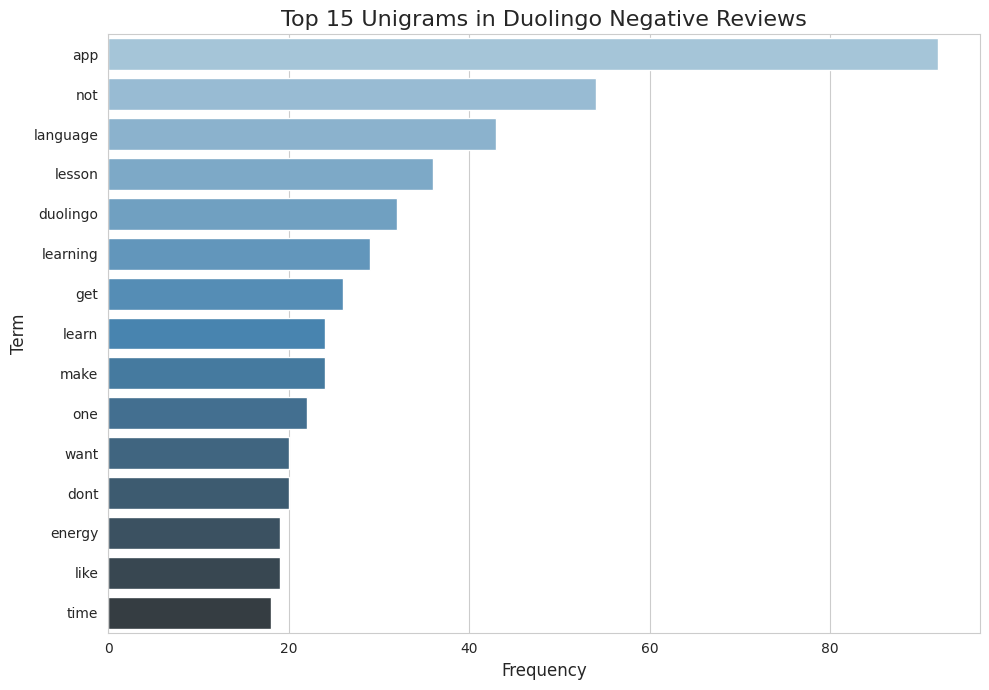

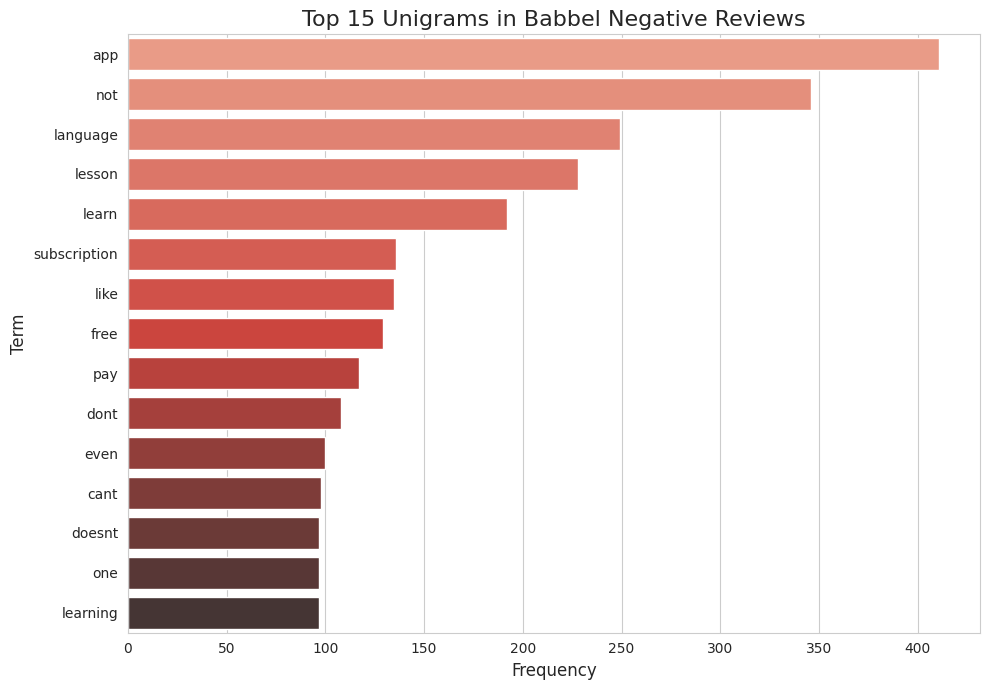

In [27]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Filter for negative reviews for Duolingo and Babbel
df_duolingo_negative = df[(df['app'] == 'Duolingo') & (df['Rating_Sentiment'] == 'Negative')]
df_babbel_negative = df[(df['app'] == 'Babbel') & (df['Rating_Sentiment'] == 'Negative')]

print("--- Analysis of Negative Reviews ---")

# Helper function to get top N-grams (unigrams, trigrams)
def get_top_ngrams(text_series, ngram_range=(1,1), top_n=15, max_features=5000, min_df=1):
    if text_series.empty:
        return pd.DataFrame(columns=['term', 'frequency'])
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()
    sums = X.sum(axis=0)
    freq_df = pd.DataFrame({'term': feature_names, 'frequency': sums.tolist()[0]})
    return freq_df.sort_values(by='frequency', ascending=False).head(top_n)


# --- Duolingo Negative Reviews Analysis ---
print("\n### Duolingo Negative Reviews Analysis ###")

# Top 15 Unigrams for Duolingo Negative Reviews
duolingo_neg_unigrams = get_top_ngrams(df_duolingo_negative['Clean_Text'], ngram_range=(1,1), top_n=15)
print("\nTop 15 Unigrams in Duolingo Negative Reviews:")
print(duolingo_neg_unigrams.to_markdown(index=False))

# Top 10 Trigrams for Duolingo Negative Reviews
duolingo_neg_trigrams = get_top_ngrams(df_duolingo_negative['Clean_Text'], ngram_range=(3,3), top_n=10)
print("\nTop 10 Trigrams in Duolingo Negative Reviews:")
print(duolingo_neg_trigrams.to_markdown(index=False))

# --- Babbel Negative Reviews Analysis ---
print("\n### Babbel Negative Reviews Analysis ###")

# Top 15 Unigrams for Babbel Negative Reviews
babbel_neg_unigrams = get_top_ngrams(df_babbel_negative['Clean_Text'], ngram_range=(1,1), top_n=15)
print("\nTop 15 Unigrams in Babbel Negative Reviews:")
print(babbel_neg_unigrams.to_markdown(index=False))

# Top 10 Trigrams for Babbel Negative Reviews
babbel_neg_trigrams = get_top_ngrams(df_babbel_negative['Clean_Text'], ngram_range=(3,3), top_n=10)
print("\nTop 10 Trigrams in Babbel Negative Reviews:")
print(babbel_neg_trigrams.to_markdown(index=False))


# --- Identifying Recurring Issue Themes ---
print("\n### Recurring Issue Themes from Negative Reviews ###")

print("\n#### Duolingo Recurring Issue Themes ####")
print("Based on the prominent unigrams ('app', 'not', 'language', 'lesson', 'duolingo', 'learning', 'make', 'learn', 'dont', 'want', 'energy', 'streak', 'doesnt', 'word', 'icon') and trigrams ('learn new language', 'app learning language', 'new language learning', 'bad app update', 'duolingo english test', 'keep saying wrong', 'get past level', 'cant get past', 'language learning app', 'please fix glitch'):")
print("- **Technical Problems/Usability**: 'energy', 'streak', 'icon', 'fix glitch', 'get past level' suggest issues with app functionality, progress tracking, and bugs.")
print("- **Learning Experience/Content**: 'lesson', 'learning', 'make', 'learn', 'word', 'learn new language', 'new language learning' indicate concerns related to the effectiveness or quality of lessons and the learning process.")
print("- **Engagement/Motivation**: 'dont', 'want', 'doesnt' combined with learning terms might point to dissatisfaction or lack of engagement.")
print("- **Updates**: 'bad app update' directly points to negative experiences with app updates.")

print("\n#### Babbel Recurring Issue Themes ####")
print("Based on the prominent unigrams ('app', 'not', 'language', 'lesson', 'subscription', 'learn', 'pay', 'dont', 'cant', 'doesnt', 'word', 'learning', 'money', 'want', 'option') and trigrams ('language learning app', 'learn new language', 'language want learn', 'much better duolingo', 'bought lifetime subscription', 'first lesson free', 'one free lesson', 'get money back', 'locked behind paywall', 'cant get past'):")
print("- **Pricing/Subscription**: 'subscription', 'pay', 'money', 'bought lifetime subscription', 'locked behind paywall', 'one free lesson' are highly prominent, indicating significant dissatisfaction related to costs, payment models, and perceived value for money.")
print("- **Learning Experience/Content**: 'lesson', 'learn', 'word', 'learning', 'language', 'learn new language' are also frequent, suggesting issues with the core learning content or methods.")
print("- **Usability/Access**: 'cant', 'option', 'cant get past' hint at difficulties with app navigation or accessing certain features.")
print("- **Comparison to Competitors**: 'much better duolingo' directly compares Babbel negatively to Duolingo, indicating users might feel Duolingo offers a superior experience or better value.")


# --- Charts for Most Frequent Negative Terms ---
print("\n### Charts of Top Negative Terms by App ###")

# Duolingo Negative Unigrams Chart
plt.figure(figsize=(10, 7))
sns.barplot(x='frequency', y='term', hue='term', data=duolingo_neg_unigrams, palette='Blues_d', legend=False)
plt.title('Top 15 Unigrams in Duolingo Negative Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.tight_layout()
plt.show()

# Babbel Negative Unigrams Chart
plt.figure(figsize=(10, 7))
sns.barplot(x='frequency', y='term', hue='term', data=babbel_neg_unigrams, palette='Reds_d', legend=False)
plt.title('Top 15 Unigrams in Babbel Negative Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.tight_layout()
plt.show()

--- Analysis of Positive Reviews ---

### Duolingo Positive Reviews Analysis ###

Top 15 Unigrams in Duolingo Positive Reviews:
| term     |   frequency |
|:---------|------------:|
| app      |         415 |
| learning |         263 |
| language |         257 |
| good     |         239 |
| learn    |         228 |
| duolingo |         150 |
| love     |         137 |
| really   |         108 |
| best     |         104 |
| english  |          93 |
| fun      |          92 |
| easy     |          91 |
| like     |          91 |
| great    |          81 |
| nice     |          70 |

Top 10 Trigrams in Duolingo Positive Reviews:
| term                        |   frequency |
|:----------------------------|------------:|
| learning new language       |          22 |
| app learning language       |          21 |
| learn new language          |          15 |
| good app learning           |          11 |
| best app learning           |          10 |
| language learning app       |          10 

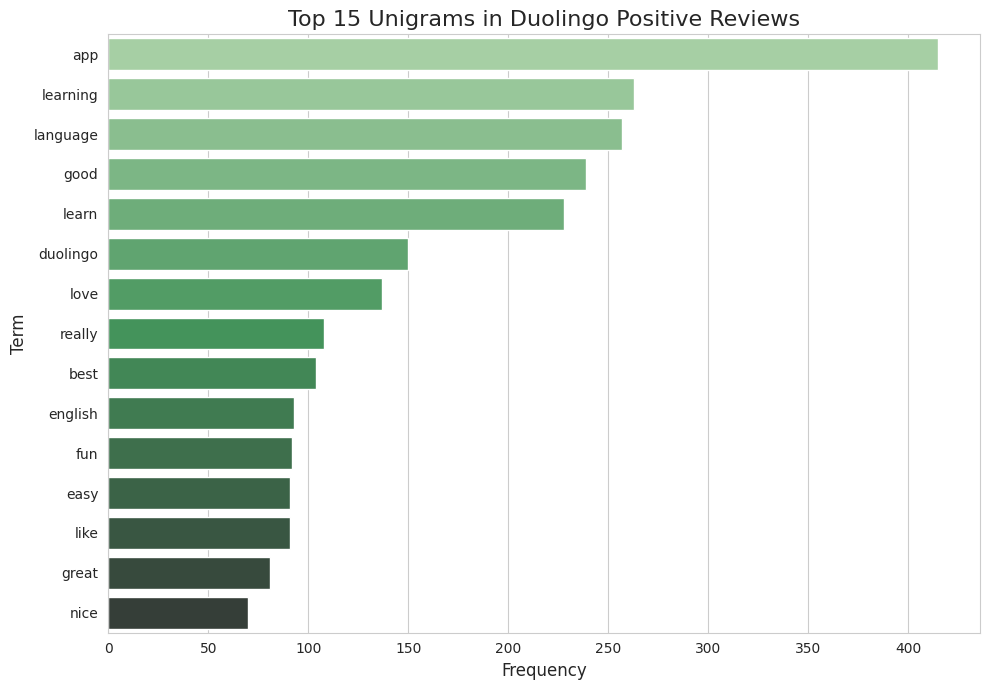

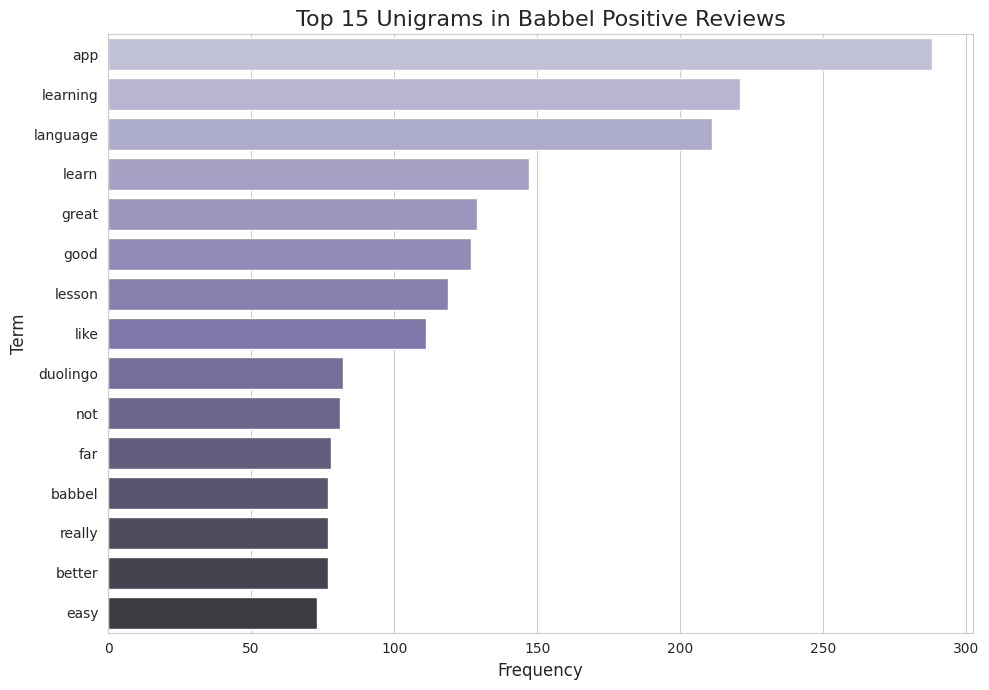

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# The get_top_ngrams function is already defined in a previous cell and is available in the kernel state.
# If it were not, it would need to be re-defined here or imported.

# Filter for positive reviews for Duolingo and Babbel
df_duolingo_positive = df[(df['app'] == 'Duolingo') & (df['Rating_Sentiment'] == 'Positive')]
df_babbel_positive = df[(df['app'] == 'Babbel') & (df['Rating_Sentiment'] == 'Positive')]

print("--- Analysis of Positive Reviews ---")

# --- Duolingo Positive Reviews Analysis ---
print("\n### Duolingo Positive Reviews Analysis ###")

# Top 15 Unigrams for Duolingo Positive Reviews
duolingo_pos_unigrams = get_top_ngrams(df_duolingo_positive['Clean_Text'], ngram_range=(1,1), top_n=15)
print("\nTop 15 Unigrams in Duolingo Positive Reviews:")
print(duolingo_pos_unigrams.to_markdown(index=False))

# Top 10 Trigrams for Duolingo Positive Reviews
duolingo_pos_trigrams = get_top_ngrams(df_duolingo_positive['Clean_Text'], ngram_range=(3,3), top_n=10)
print("\nTop 10 Trigrams in Duolingo Positive Reviews:")
print(duolingo_pos_trigrams.to_markdown(index=False))

# --- Babbel Positive Reviews Analysis ---
print("\n### Babbel Positive Reviews Analysis ###")

# Top 15 Unigrams for Babbel Positive Reviews
babbel_pos_unigrams = get_top_ngrams(df_babbel_positive['Clean_Text'], ngram_range=(1,1), top_n=15)
print("\nTop 15 Unigrams in Babbel Positive Reviews:")
print(babbel_pos_unigrams.to_markdown(index=False))

# Top 10 Trigrams for Babbel Positive Reviews
babbel_pos_trigrams = get_top_ngrams(df_babbel_positive['Clean_Text'], ngram_range=(3,3), top_n=10)
print("\nTop 10 Trigrams in Babbel Positive Reviews:")
print(babbel_pos_trigrams.to_markdown(index=False))


# --- Identifying Recurring Positive Themes ---
print("\n### Recurring Positive Themes from Reviews ###")

print("\n#### Duolingo Recurring Positive Themes ####")
print("Based on the prominent unigrams ('app', 'learning', 'language', 'learn', 'duolingo', 'best', 'english', 'fun', 'nice', 'help', 'make', 'helpful', 'word', 'lesson', 'super') and trigrams ('learning new language', 'app learning language', 'learn new language', 'best app learning', 'language learning app', 'good app learning', 'best language learning', 'great app learning', 'great learning app', 'easy learn language'):")
print("- **Effective Learning Experience**: Frequent mentions of 'learning', 'learn', 'language', 'lesson', 'english', 'word' and phrases like 'learning new language', 'learn new language', 'language learning app' highlight that users find the app effective for language acquisition and content delivery.")
print("- **Ease of Use & Enjoyment**: Terms like 'fun', 'easy', 'nice', 'best app learning', 'great app learning' suggest that users find the app user-friendly and enjoyable, making the learning process engaging.")
print("- **Recommendation/Value**: 'best' and 'helpful' imply that users highly value the app and would recommend it for language learning.")
print("- **App Functionality**: 'app', 'super' indicate a general satisfaction with the application's performance and design.")

print("\n#### Babbel Recurring Positive Themes ####")
print("Based on the prominent unigrams ('app', 'learning', 'language', 'learn', 'lesson', 'duolingo', 'babbel', 'grammar', 'word', 'spanish', 'ive', 'fun', 'best', 'make', 'help') and trigrams ('language learning app', 'learn new language', 'learning new language', 'best language learning', 'learn spanish language', 'learn german language', 'speak new language', 'language want learn', 'good language learning', 'easy learn language'):")
print("- **Solid Learning & Lesson Quality**: 'learning', 'language', 'learn', 'lesson', 'grammar', 'word' and phrases like 'language learning app', 'learn new language', 'best language learning' point to users appreciating the quality and structure of Babbel's lessons and its ability to teach effectively.")
print("- **Specific Language Focus**: 'spanish', 'learn spanish language', 'learn german language' indicate that users find Babbel particularly effective for learning specific languages.")
print("- **Practical Application**: 'speak new language' suggests that users feel Babbel helps them achieve conversational skills, which is a practical outcome.")
print("- **Comparison/Effectiveness**: The presence of 'duolingo' here (even in positive reviews for Babbel) suggests some users might be evaluating Babbel against Duolingo and finding it superior for their needs, although this is less direct than 'much better duolingo' in negative reviews.")
print("- **Engagement & Enjoyment**: 'fun', 'make' imply that the learning process is engaging and enjoyable for users.")


# --- Charts for Most Frequent Positive Terms ---
print("\n### Charts of Top Positive Terms by App ###")

# Duolingo Positive Unigrams Chart
plt.figure(figsize=(10, 7))
sns.barplot(x='frequency', y='term', hue='term', data=duolingo_pos_unigrams, palette='Greens_d', legend=False)
plt.title('Top 15 Unigrams in Duolingo Positive Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.tight_layout()
plt.show()

# Babbel Positive Unigrams Chart
plt.figure(figsize=(10, 7))
sns.barplot(x='frequency', y='term', hue='term', data=babbel_pos_unigrams, palette='Purples_d', legend=False)
plt.title('Top 15 Unigrams in Babbel Positive Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.tight_layout()
plt.show()

## Overall Interpretation and Insights

This comparative analysis of Duolingo and Babbel reviews reveals distinct strengths and weaknesses for each language learning application, as perceived by their users. By examining sentiment, unigram, and trigram frequencies, we can infer key themes driving user satisfaction and dissatisfaction.

### Duolingo: Strengths & Weaknesses

**Strengths (Positive Reviews)**:
*   **Effective & Enjoyable Learning**: Users frequently commend Duolingo for making language learning `fun`, `easy`, and `effective`. Phrases like `learning new language`, `app learning language`, and `best app learning` highlight its perceived success in delivering a valuable educational experience. The emphasis on `game` and `make learning fun` also suggests a strong positive association with its gamified approach.
*   **App Functionality & User Experience**: General positive sentiment towards the `app` itself, coupled with words like `best`, `nice`, `helpful`, and `great`, indicates satisfaction with its design, usability, and overall performance.
*   **Specific Language Learning**: Mentions of `english` and `spanish` in positive contexts suggest it's particularly valued for these languages.

**Weaknesses (Negative Reviews)**:
*   **Technical Issues & System Frustrations**: Recurring negative themes point to `energy`, `streak` (management/loss), and `icon` issues, suggesting problems with app mechanics and progress tracking. Trigrams like `bad app update`, `fix glitch`, and `cant get past` further emphasize technical and usability frustrations.
*   **Learning Experience Concerns**: While generally praised, some negative feedback related to `lesson`, `make`, `learn`, and `word` implies that the learning content or methodology doesn't satisfy all users.
*   **External Policies**: `duolingo english test` and associated phrases appearing prominently in negative trigrams indicate significant user dissatisfaction related to changes in test policies or the experience of the test itself.

### Babbel: Strengths & Weaknesses

**Strengths (Positive Reviews)**:
*   **Solid Learning & Lesson Quality**: Babbel receives strong praise for its `lesson` quality, structured `learning`, `grammar`, and `vocabulary` building. Phrases such as `language learning app`, `learn new language`, and `best language learning` reflect a strong appreciation for its pedagogical approach and content depth.
*   **Practical Application**: Users appreciate Babbel's focus on `speaking` and its effectiveness in helping them `learn spanish language` or `learn german language`, indicating a successful real-world application of the skills taught.
*   **Comparison Advantage**: Interestingly, the term `duolingo` appears in Babbel's positive reviews, implying that some users find Babbel superior to Duolingo for their learning needs.

**Weaknesses (Negative Reviews)**:
*   **Pricing & Subscription Issues**: This is Babbel's most prominent area of concern. Terms like `subscription`, `pay`, `money`, `free lesson`, `lifetime subscription`, and phrases like `locked behind paywall`, `get money back` overwhelmingly dominate negative feedback. Users are clearly frustrated with costs, subscription models, and perceived lack of free content/value.
*   **Usability/Access Restrictions**: `cant get past`, `option`, and general mentions of `app` alongside negative terms suggest difficulties with accessing content or specific app functionalities, often linked to its pricing model.
*   **Direct Comparison to Duolingo**: The trigram `much better duolingo` explicitly highlights that a segment of users negatively compares Babbel to its competitor, often in the context of cost or overall experience.

### Comparison and Contrasting Insights

*   **Learning Experience**: Both apps are generally praised for their `learning` and `language` aspects in positive reviews. However, Duolingo's positive feedback leans towards `fun` and `easy` learning, suggesting an engaging, gamified experience, while Babbel's positive feedback emphasizes `lesson` quality, `grammar`, and `speaking`, indicating a more structured, practical, and effective approach for some users.
*   **Points of Frustration**: Duolingo's negative feedback is more scattered, often revolving around app mechanics, `streak` preservation, and test policies. Babbel's negative feedback is much more concentrated on financial aspects: `subscription`, `pay`, and `money` are overwhelmingly dominant.
*   **Sentiment Metrics**: Duolingo exhibits a significantly higher percentage of positive rating-based (82.52%) and VADER (79.53%) sentiment compared to Babbel (42.59% rating-based, 58.89% VADER positive). This suggests Duolingo generally fosters higher overall satisfaction, though VADER's higher positive score for Babbel indicates that its text content is often more positive than its rating might suggest, potentially due to users expressing nuanced feedback within reviews.
*   **Mismatch in Sentiment**: While both apps show sentiment disagreement between rating and VADER, Babbel has a considerably higher mismatch percentage (40.08%) compared to Duolingo (20.55%). This implies that Babbel's reviews are more likely to contain text sentiment that doesn't align with the numerical rating given, often indicating reviews where users express mixed feelings or specific criticisms/praises that aren't fully captured by the star rating alone.

In conclusion, while both applications successfully address language learning needs, Duolingo excels in user engagement and overall positive experience, occasionally facing technical and policy-related complaints. Babbel, while highly regarded for its structured and effective lessons, struggles significantly with user perception around its pricing and subscription model, which overshadows many of its pedagogical strengths.